# **PART I — DATA UNDERSTANDING & EXPLORATORY DATA ANALYSIS**

This part introduces the credit-risk prediction problem, loads the project datasets, examines their structure and roles, and performs exploratory data analysis before any model training or formal feature selection.

# **1. Project Objective and Evaluation Framework**

## **1.1 Prediction Objective**

The objective of this project is to develop a binary classification system for predicting the credit risk of loan applicants.

The model estimates whether an applicant belongs to the:

- **Good-credit class**, or
- **Bad-credit class**

The prediction system will later be evaluated using a fixed Nested Cross-Validation framework before a final model is selected.

## **1.2 Target Definition**

The target variable is:

- `bad_credit = 0` → Good credit
- `bad_credit = 1` → Bad credit

In this project, **Bad credit (`1`) is treated as the positive class**.

Therefore:

- **TP**: Bad applicant correctly predicted as Bad
- **TN**: Good applicant correctly predicted as Good
- **FP**: Good applicant incorrectly predicted as Bad
- **FN**: Bad applicant incorrectly predicted as Good

## **1.3 Business Cost**

The project uses an asymmetric misclassification cost:

\[
Cost = 5 \times FN + FP
\]

where:

- `FN` represents a Bad-credit applicant incorrectly classified as Good,
- `FP` represents a Good-credit applicant incorrectly classified as Bad.

A False Negative is therefore considered five times more costly than a False Positive.

This cost function will later be used for classification-threshold selection and model comparison.

## **1.4 Evaluation Metrics**

Because the business objective is cost-sensitive and the target may be imbalanced, model performance will not be judged by accuracy alone.

The following metrics will be considered:

- Accuracy
- Precision
- Recall
- F1-score
- ROC-AUC
- Average Precision
- Brier Score
- Business Cost

The primary decision criterion is the business cost:

\[
Cost = 5FN + FP
\]

Probability-based metrics such as ROC-AUC, Average Precision, and Brier Score will also be used to evaluate the quality of predicted probabilities.

# **2. Data Loading**

The project uses three predefined datasets:

- Development data
- Historical benchmark data
- Competition data

These datasets have different roles and must remain separated throughout the modelling process.

## **2.1 Import Libraries**

In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    brier_score_loss
)

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.width", 150)

## **2.2 Project paths**

In [2]:
PROJECT_ROOT = Path(r"D:\SCHOOLWORK\Thống kê\Midterm Project")

DATA_PATH = PROJECT_ROOT / "data_splits_colab" / "data_split"

## **2.3 Load Development, Benchmark, and Competition Data**


In [3]:
development = pd.read_csv(
    DATA_PATH / "development_640.csv"
)

benchmark = pd.read_csv(
    DATA_PATH / "historical_benchmark_160.csv"
)

competition = pd.read_csv(
    DATA_PATH / "competition_200.csv"
)

In [4]:
print("Development:", development.shape)
print("Benchmark:", benchmark.shape)
print("Competition:", competition.shape)

Development: (640, 22)
Benchmark: (160, 22)
Competition: (200, 21)


## **2.4. Rename Columns**

In [5]:
rename_map = {
    "laufkont": "status",
    "laufzeit": "duration",
    "moral": "credit_history",
    "verw": "purpose",
    "hoehe": "amount",
    "sparkont": "savings",
    "beszeit": "employment_duration",
    "rate": "installment_rate",
    "famges": "personal_status_sex",
    "buerge": "other_debtors",
    "wohnzeit": "present_residence",
    "verm": "property",
    "alter": "age",
    "weitkred": "other_installment_plans",
    "wohn": "housing",
    "bishkred": "number_credits",
    "beruf": "job",
    "pers": "people_liable",
    "telef": "telephone",
    "gastarb": "foreign_worker"
}

In [6]:
development = development.rename(
    columns=rename_map
)

benchmark = benchmark.rename(
    columns=rename_map
)

competition = competition.rename(
    columns=rename_map
)

In [7]:
development.columns.tolist()

['Id',
 'status',
 'duration',
 'credit_history',
 'purpose',
 'amount',
 'savings',
 'employment_duration',
 'installment_rate',
 'personal_status_sex',
 'other_debtors',
 'present_residence',
 'property',
 'age',
 'other_installment_plans',
 'housing',
 'number_credits',
 'job',
 'people_liable',
 'telephone',
 'foreign_worker',
 'bad_credit']

# **3. Dataset Structure and Roles**

Before performing EDA or model training, the structure and intended role of each dataset are examined.

Maintaining the separation between these datasets is important for preventing information leakage.

## **3.1 Dataset Dimensions**

In [8]:
dataset_dimensions = pd.DataFrame({
    "Dataset": [
        "Development",
        "Historical Benchmark",
        "Competition"
    ],
    "Rows": [
        development.shape[0],
        benchmark.shape[0],
        competition.shape[0]
    ],
    "Columns": [
        development.shape[1],
        benchmark.shape[1],
        competition.shape[1]
    ]
})

dataset_dimensions

,Dataset,Rows,Columns
0,Development,640,22
1,Historical Benchmark,160,22
2,Competition,200,21


## **3.2 Column Overview**

In [9]:
print("Development columns:")
print(development.columns.tolist())

print("\nBenchmark columns:")
print(benchmark.columns.tolist())

print("\nCompetition columns:")
print(competition.columns.tolist())

Development columns:
['Id', 'status', 'duration', 'credit_history', 'purpose', 'amount', 'savings', 'employment_duration', 'installment_rate', 'personal_status_sex', 'other_debtors', 'present_residence', 'property', 'age', 'other_installment_plans', 'housing', 'number_credits', 'job', 'people_liable', 'telephone', 'foreign_worker', 'bad_credit']

Benchmark columns:
['Id', 'status', 'duration', 'credit_history', 'purpose', 'amount', 'savings', 'employment_duration', 'installment_rate', 'personal_status_sex', 'other_debtors', 'present_residence', 'property', 'age', 'other_installment_plans', 'housing', 'number_credits', 'job', 'people_liable', 'telephone', 'foreign_worker', 'bad_credit']

Competition columns:
['Id', 'status', 'duration', 'credit_history', 'purpose', 'amount', 'savings', 'employment_duration', 'installment_rate', 'personal_status_sex', 'other_debtors', 'present_residence', 'property', 'age', 'other_installment_plans', 'housing', 'number_credits', 'job', 'people_liable', '

In [10]:
target_check = pd.DataFrame({
    "Dataset": [
        "Development",
        "Historical Benchmark",
        "Competition"
    ],
    "Contains bad_credit": [
        "bad_credit" in development.columns,
        "bad_credit" in benchmark.columns,
        "bad_credit" in competition.columns
    ]
})

target_check

,Dataset,Contains bad_credit
0,Development,True
1,Historical Benchmark,True
2,Competition,False


In [11]:
display(development.head())

,Id,status,duration,credit_history,purpose,amount,savings,employment_duration,installment_rate,personal_status_sex,other_debtors,present_residence,property,age,other_installment_plans,housing,number_credits,job,people_liable,telephone,foreign_worker,bad_credit
0,0,1,18,4,2,1049,1,2,4,2,1,4,2,21,3,1,1,3,2,1,2,0
1,2,2,12,2,9,841,2,4,2,2,1,4,1,23,3,1,1,2,2,1,2,0
2,3,1,12,4,0,2122,1,3,3,3,1,2,1,39,3,1,2,2,1,1,1,0
3,5,1,10,4,0,2241,1,2,1,3,1,3,1,48,3,1,2,2,1,1,1,0
4,6,1,8,4,0,3398,1,4,1,3,1,4,1,39,3,2,2,2,2,1,1,0


In [12]:
development.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 640 entries, 0 to 639
Data columns (total 22 columns):
 #   Column                   Non-Null Count  Dtype
---  ------                   --------------  -----
 0   Id                       640 non-null    int64
 1   status                   640 non-null    int64
 2   duration                 640 non-null    int64
 3   credit_history           640 non-null    int64
 4   purpose                  640 non-null    int64
 5   amount                   640 non-null    int64
 6   savings                  640 non-null    int64
 7   employment_duration      640 non-null    int64
 8   installment_rate         640 non-null    int64
 9   personal_status_sex      640 non-null    int64
 10  other_debtors            640 non-null    int64
 11  present_residence        640 non-null    int64
 12  property                 640 non-null    int64
 13  age                      640 non-null    int64
 14  other_installment_plans  640 non-null    int64
 15  housin

## **3.3 Development / Benchmark / Competition Roles**

The datasets have fixed and distinct roles.

### Development Data

The development dataset is used for:

- Exploratory Data Analysis,
- preprocessing design,
- model selection,
- threshold selection,
- Nested Cross-Validation,
- feature-selection experiments,
- and final model selection.

### Historical Benchmark

The historical benchmark is kept outside the model-selection process.

It is used only after the final modelling rule has been frozen, providing an additional diagnostic evaluation.

Benchmark performance must not be used to return to model tuning or feature selection.

### Competition Data

The competition dataset does not contain the target variable.

It is used only for generating the final predictions after the modelling procedure has been completed.

# **4. Exploratory Data Analysis**

Exploratory Data Analysis is performed to understand the quality, distribution, structure, and potential predictive patterns of the development dataset before model training.

The objectives are to:

- assess data quality,
- examine target-class balance,
- study numerical feature distributions,
- investigate categorical feature patterns,
- examine feature–target relationships,
- and identify variables that may require further investigation.

EDA is used to generate hypotheses rather than make final feature-removal decisions.

No predictor will be removed solely because it appears weak in exploratory plots.

## **4.1 Data Quality Assessment**

The development dataset is first examined for:

- missing values,
- duplicated observations,
- duplicated IDs,
- data types,
- and the number of unique values in each variable.

**Quality Summary**

In [13]:
quality_summary = pd.DataFrame({
    "Data_Type": development.dtypes.astype(str),
    "Missing_Count": development.isna().sum(),
    "Missing_Percentage": (
        development.isna().mean() * 100
    ).round(2),
    "Unique_Values": development.nunique()
})

quality_summary

,Data_Type,Missing_Count,Missing_Percentage,Unique_Values
Id,int64,0,0.0,640
status,int64,0,0.0,4
duration,int64,0,0.0,30
credit_history,int64,0,0.0,5
purpose,int64,0,0.0,10
amount,int64,0,0.0,616
savings,int64,0,0.0,5
employment_duration,int64,0,0.0,5
installment_rate,int64,0,0.0,4
personal_status_sex,int64,0,0.0,4


### **Data Quality Findings**

The development dataset contains no missing values across all variables.

The `Id` column contains 640 unique values, confirming that it serves as an observation identifier rather than a predictive feature.

Although all predictors are currently stored as integer values, many variables represent coded categorical characteristics rather than continuous numerical quantities. Therefore, data type alone will not be used to determine the preprocessing strategy.

The main continuous numerical predictors are:

- `duration`
- `amount`
- `age`

The remaining predictors will be treated as categorical variables during modelling.

**Duplicates**

In [14]:
print(
    "Duplicated rows:",
    development.duplicated().sum()
)

print(
    "Duplicated IDs:",
    development["Id"].duplicated().sum()
)

Duplicated rows: 0
Duplicated IDs: 0


**Descriptive Overview**

In [15]:
development.describe(include="all").T

,count,mean,std,min,25%,50%,75%,max
Id,640.0,477.593750,278.164249,0.0,236.75,472.5,708.25,999.0
status,640.0,2.631250,1.244063,1.0,2.00,2.0,4.00,4.0
duration,640.0,20.756250,12.414085,4.0,12.00,18.0,24.00,72.0
credit_history,640.0,2.606250,1.119450,0.0,2.00,2.0,4.00,4.0
purpose,640.0,2.806250,2.727583,0.0,1.00,2.0,3.00,10.0
amount,640.0,3247.590625,2874.526174,276.0,1360.75,2283.0,3926.50,18424.0
savings,640.0,2.145313,1.585086,1.0,1.00,1.0,3.00,5.0
employment_duration,640.0,3.378125,1.224741,1.0,3.00,3.0,5.00,5.0
installment_rate,640.0,2.943750,1.138304,1.0,2.00,3.0,4.00,4.0
personal_status_sex,640.0,2.692188,0.699162,1.0,2.00,3.0,3.00,4.0


## **4.2 Target Variable Analysis**

The distribution of the target variable is examined to determine the level of class imbalance in the development dataset.

This is particularly important because the positive class represents Bad-credit applicants and False Negatives have a substantially higher business cost.

**Counts and Percentages**

In [16]:
target_counts = (
    development["bad_credit"]
    .value_counts()
    .sort_index()
)

target_percentages = (
    development["bad_credit"]
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
)

target_summary = pd.DataFrame({
    "Class": [
        "Good Credit",
        "Bad Credit"
    ],
    "Count": [
        target_counts.get(0, 0),
        target_counts.get(1, 0)
    ],
    "Percentage": [
        target_percentages.get(0, 0),
        target_percentages.get(1, 0)
    ]
})

target_summary

,Class,Count,Percentage
0,Good Credit,480,75.0
1,Bad Credit,160,25.0


### **Target Distribution Findings**

The development dataset contains:

- 480 Good-credit applicants (75%)
- 160 Bad-credit applicants (25%)

The target therefore exhibits a moderate class imbalance, with Good-credit applicants occurring approximately three times as often as Bad-credit applicants.

This imbalance reinforces the need to evaluate models using metrics beyond accuracy.

In particular, Recall for the Bad-credit class and the asymmetric business cost

\[
Cost = 5FN + FP
\]

will be important because failing to identify a Bad-credit applicant is substantially more costly than incorrectly rejecting a Good-credit applicant.

## **4.3 Numerical Feature Analysis**

The three continuous numerical predictors are:

- `duration`
- `amount`
- `age`

These variables are examined using descriptive statistics, distribution plots, boxplots, and class-wise comparisons.

The objectives are to investigate:

- their overall distributions,
- possible skewness,
- potential outliers,
- and differences between Good-credit and Bad-credit applicants.

### **4.3.1 Numerical Summary Statistics**

In [17]:
numeric_features = [
    "duration",
    "amount",
    "age"
]

numeric_summary = (
    development[numeric_features]
    .describe()
    .T
)

numeric_summary

,count,mean,std,min,25%,50%,75%,max
duration,640.0,20.756250,12.414085,4.0,12.00,18.0,24.0,72.0
amount,640.0,3247.590625,2874.526174,276.0,1360.75,2283.0,3926.5,18424.0
age,640.0,35.653125,11.234100,19.0,27.00,33.0,42.0,75.0


In [18]:
numeric_summary["skewness"] = (
    development[numeric_features]
    .skew()
)

numeric_summary

,count,mean,std,min,25%,50%,75%,max,skewness
duration,640.0,20.756250,12.414085,4.0,12.00,18.0,24.0,72.0,1.171777
amount,640.0,3247.590625,2874.526174,276.0,1360.75,2283.0,3926.5,18424.0,2.083587
age,640.0,35.653125,11.234100,19.0,27.00,33.0,42.0,75.0,0.991234


### **4.3.2 Numerical Distribution**

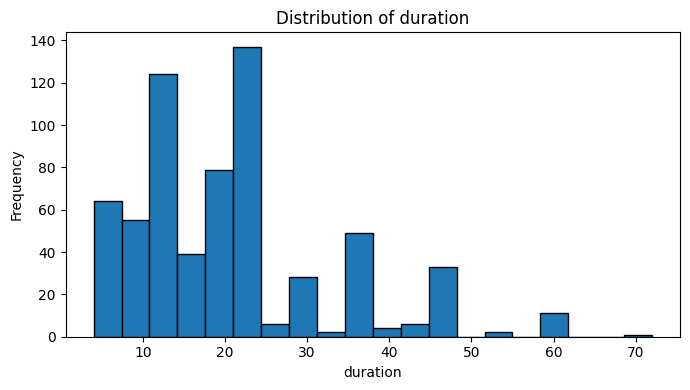

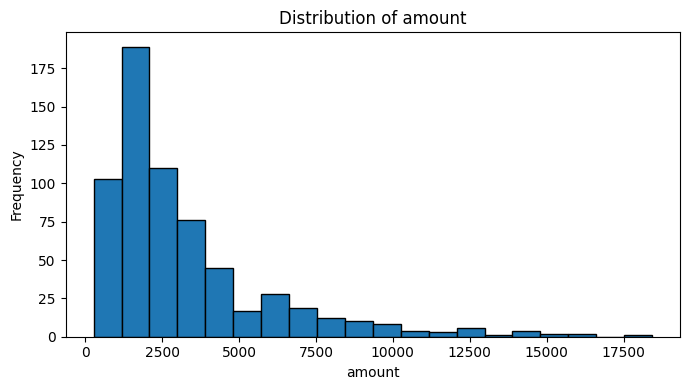

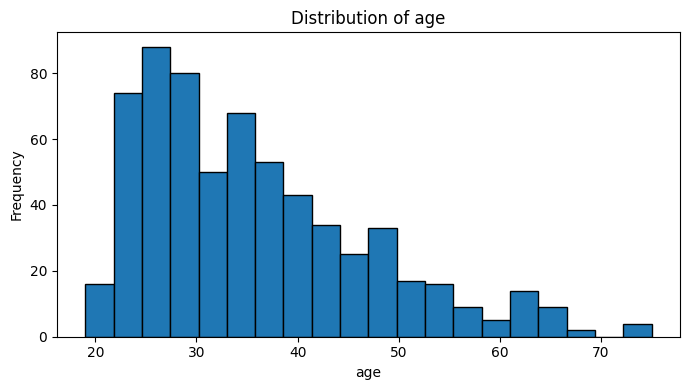

In [19]:
for feature in numeric_features:

    plt.figure(figsize=(7, 4))

    plt.hist(
        development[feature],
        bins=20,
        edgecolor="black"
    )

    plt.title(
        f"Distribution of {feature}"
    )

    plt.xlabel(feature)
    plt.ylabel("Frequency")

    plt.tight_layout()
    plt.show()

### **4.3.3 Numerical Boxplots**

Boxplots are used to examine the spread of each numerical variable and identify observations located beyond the conventional interquartile-range boundaries.

Potential outliers are investigated but are not automatically removed, because unusually large or small values may represent valid credit applicants rather than data errors.

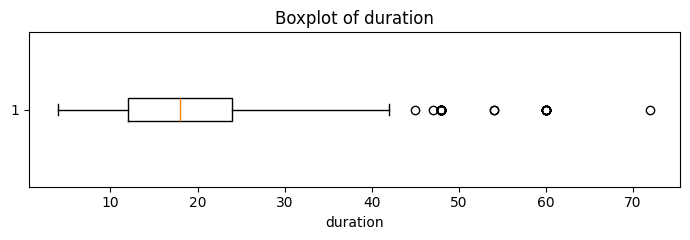

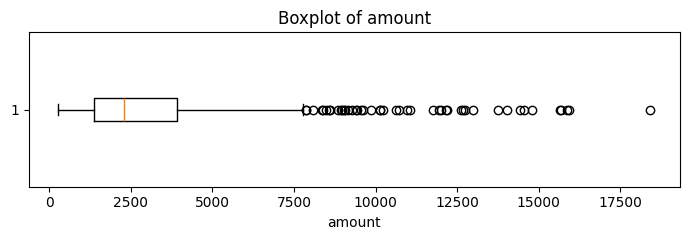

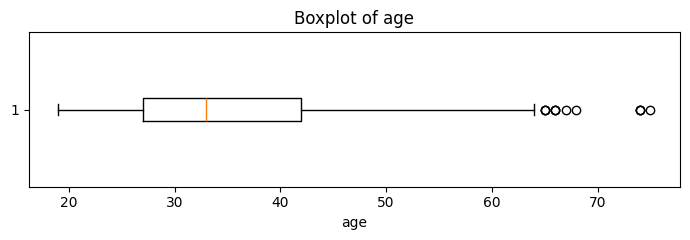

In [20]:
for feature in numeric_features:

    plt.figure(figsize=(7, 2.5))

    plt.boxplot(
        development[feature],
        vert=False
    )

    plt.title(
        f"Boxplot of {feature}"
    )

    plt.xlabel(feature)

    plt.tight_layout()
    plt.show()

### **4.3.4 Numerical Features by Credit Class**

The distributions of numerical predictors are compared between Good-credit and Bad-credit applicants.

This analysis is exploratory and is used to identify potential class-related patterns rather than make direct feature-removal decisions.

In [21]:
numeric_by_target = (
    development
    .groupby("bad_credit")[numeric_features]
    .agg(["mean", "median", "std"])
)

numeric_by_target

duration                         amount                           age                  
                 mean median        std         mean  median          std     mean median        std
bad_credit                                                                                          
0           19.283333   18.0  11.549066  3004.089583  2244.0  2469.914874  36.3000   34.0  11.325217
1           25.175000   24.0  13.832125  3978.093750  2496.5  3756.773168  33.7125   30.0  10.758871

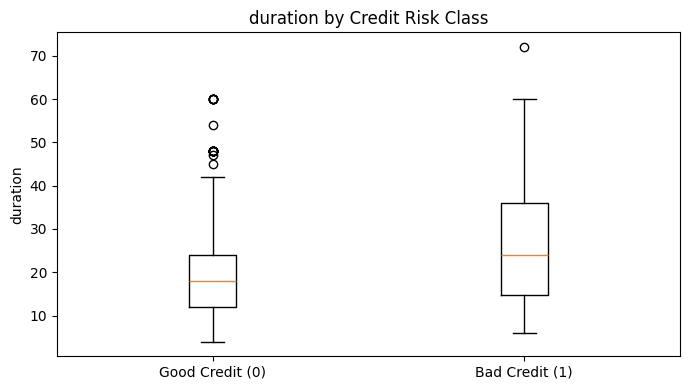

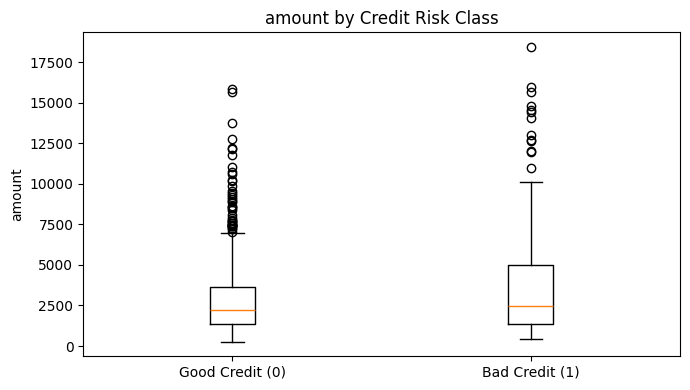

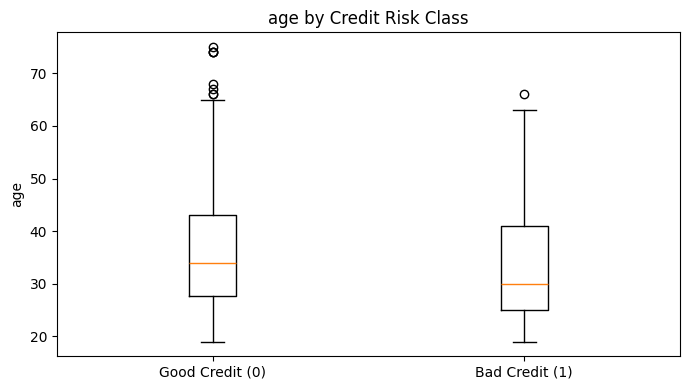

In [22]:
for feature in numeric_features:

    good_values = development.loc[
        development["bad_credit"] == 0,
        feature
    ]

    bad_values = development.loc[
        development["bad_credit"] == 1,
        feature
    ]

    plt.figure(figsize=(7, 4))

    plt.boxplot(
        [good_values, bad_values],
        labels=[
            "Good Credit (0)",
            "Bad Credit (1)"
        ]
    )

    plt.title(
        f"{feature} by Credit Risk Class"
    )

    plt.ylabel(feature)

    plt.tight_layout()
    plt.show()

### **4.3.5 Numerical Correlation**

Pairwise correlations between the continuous numerical predictors are examined to identify strong linear relationships and possible redundancy.

Only the continuous numerical variables are included because integer-coded categorical variables should not be interpreted using ordinary Pearson correlation as if their numerical codes represented continuous quantities.

In [23]:
numeric_correlation = (
    development[numeric_features]
    .corr()
)

numeric_correlation

,duration,amount,age
duration,1.000000,0.647294,0.000896
amount,0.647294,1.000000,0.031562
age,0.000896,0.031562,1.000000


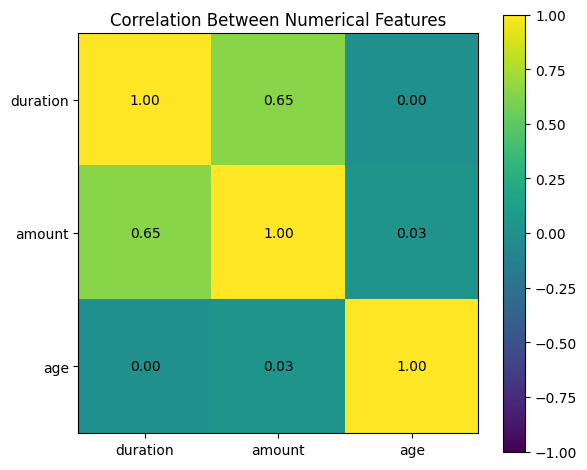

In [24]:
fig, ax = plt.subplots(figsize=(6, 5))

image = ax.imshow(
    numeric_correlation,
    vmin=-1,
    vmax=1
)

ax.set_xticks(
    range(len(numeric_features))
)

ax.set_yticks(
    range(len(numeric_features))
)

ax.set_xticklabels(
    numeric_features
)

ax.set_yticklabels(
    numeric_features
)

for i in range(len(numeric_features)):
    for j in range(len(numeric_features)):
        ax.text(
            j,
            i,
            f"{numeric_correlation.iloc[i, j]:.2f}",
            ha="center",
            va="center"
        )

plt.title(
    "Correlation Between Numerical Features"
)

plt.colorbar(image)
plt.tight_layout()
plt.show()

### **Numerical Feature Findings**

The numerical variables show meaningful differences between Good-credit and Bad-credit applicants.

- `duration` is moderately right-skewed. Bad-credit applicants have noticeably longer credit durations, with a mean duration of approximately 25.2 months compared with 19.3 months for Good-credit applicants.

- `amount` is strongly right-skewed and contains several relatively large loan values. Bad-credit applicants have a higher average credit amount than Good-credit applicants. However, the difference in medians is smaller than the difference in means, suggesting that large loan amounts may influence the average.

- `age` is also right-skewed. Good-credit applicants are somewhat older on average and in terms of median age than Bad-credit applicants.

Overall, all three numerical predictors show potentially useful differences between the two credit-risk classes.

No numerical feature is removed at this stage. Potential outliers are retained because they may represent valid applicants rather than data errors.

## **4.4 Categorical Feature Analysis**

The remaining predictors are categorical variables represented by integer codes.

Although these variables are stored as integers, their values represent categories rather than continuous numerical quantities.

The categorical analysis examines:

- category frequencies,
- category imbalance,
- Bad-credit rates across categories,
- and potentially rare or low-information variables.

### **4.4.1 Define Categorical Features**

In [25]:
categorical_features = [
    col for col in development.columns
    if col not in (
        ["Id", "bad_credit"]
        + numeric_features
    )
]

print(
    "Number of categorical features:",
    len(categorical_features)
)

categorical_features

Number of categorical features: 17


['status',
 'credit_history',
 'purpose',
 'savings',
 'employment_duration',
 'installment_rate',
 'personal_status_sex',
 'other_debtors',
 'present_residence',
 'property',
 'other_installment_plans',
 'housing',
 'number_credits',
 'job',
 'people_liable',
 'telephone',
 'foreign_worker']

### **4.4.2 Category Frequency Summary**

The frequency structure of each categorical predictor is examined to identify:

- the number of categories,
- the most common category,
- and the degree of concentration in the dominant category.

A highly dominant category may indicate limited variability, but this does not automatically imply that the feature should be removed.

In [26]:
category_summary = []

for feature in categorical_features:

    counts = development[feature].value_counts()

    category_summary.append({
        "Feature": feature,
        "Number_of_Categories": development[feature].nunique(),
        "Most_Common_Category": counts.index[0],
        "Most_Common_Count": counts.iloc[0],
        "Most_Common_Percentage": (
            counts.iloc[0] / len(development) * 100
        )
    })

category_summary = pd.DataFrame(
    category_summary
)

category_summary

,Feature,Number_of_Categories,Most_Common_Category,Most_Common_Count,Most_Common_Percentage
0,status,4,4,261,40.78125
1,credit_history,5,2,315,49.21875
2,purpose,10,3,180,28.12500
3,savings,5,1,372,58.12500
4,employment_duration,5,3,199,31.09375
5,installment_rate,4,4,301,47.03125
6,personal_status_sex,4,3,354,55.31250
7,other_debtors,3,1,578,90.31250
8,present_residence,4,4,258,40.31250
9,property,4,3,215,33.59375


### **4.4.3 Category Distributions**

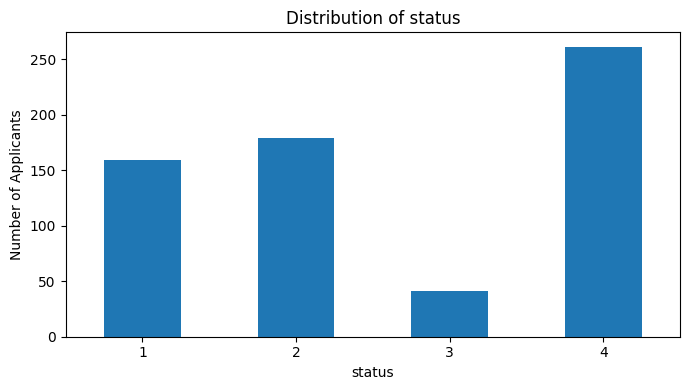

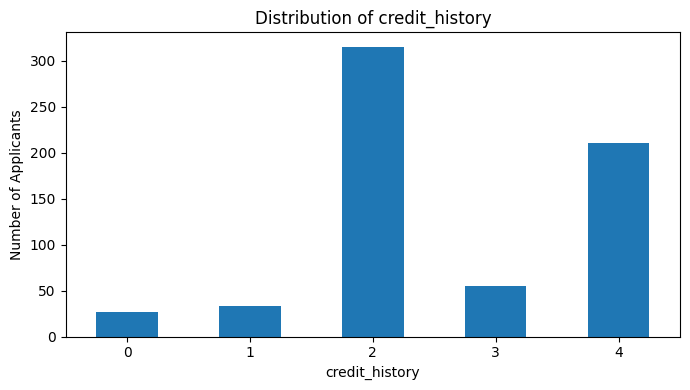

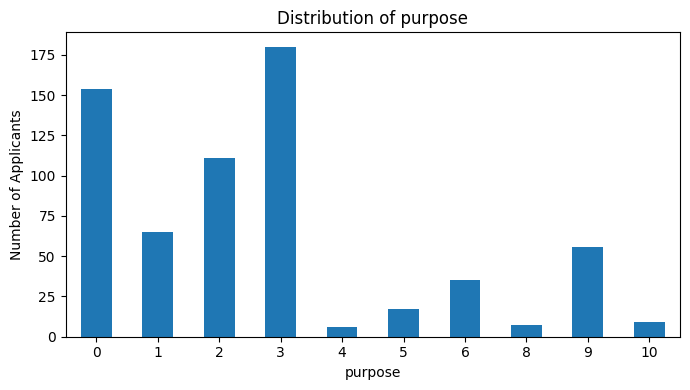

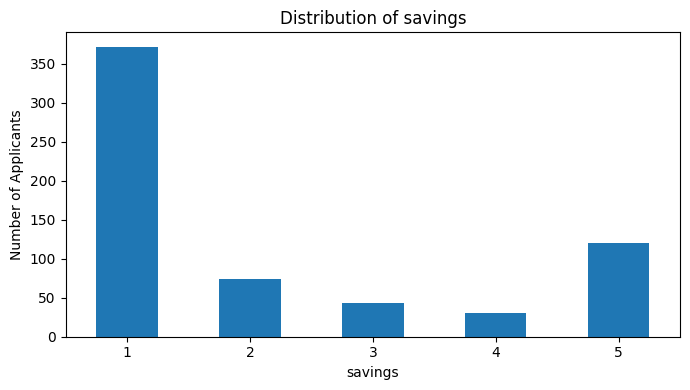

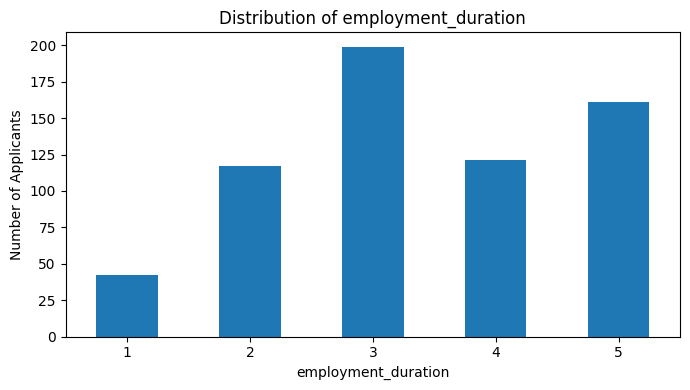

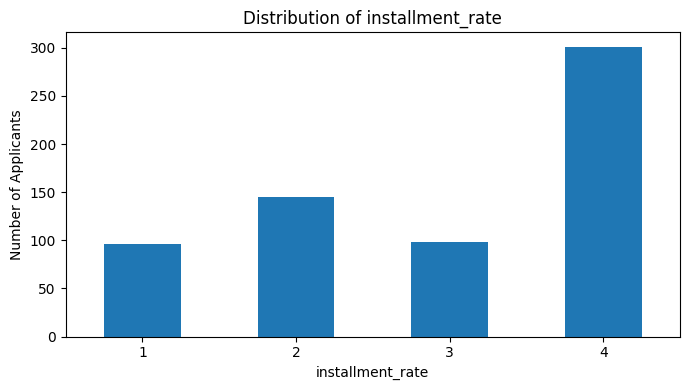

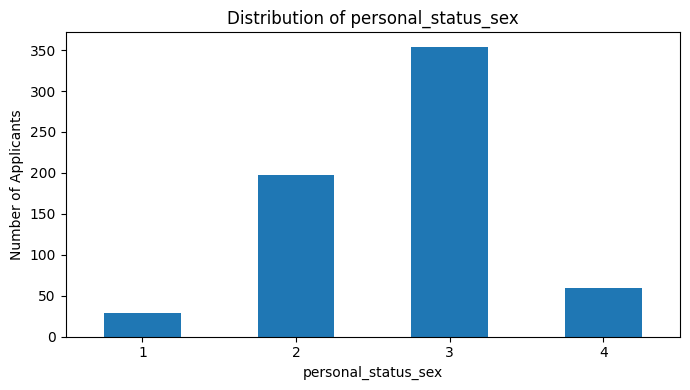

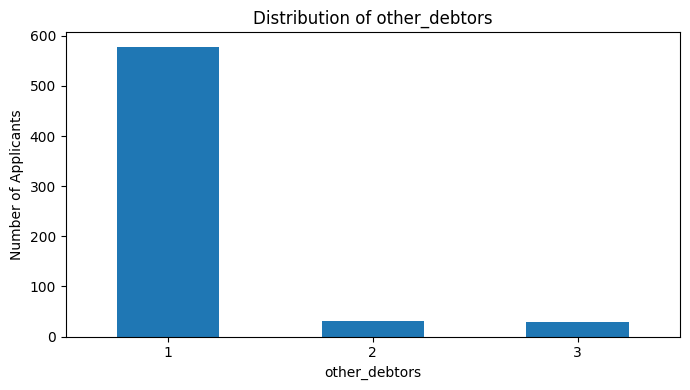

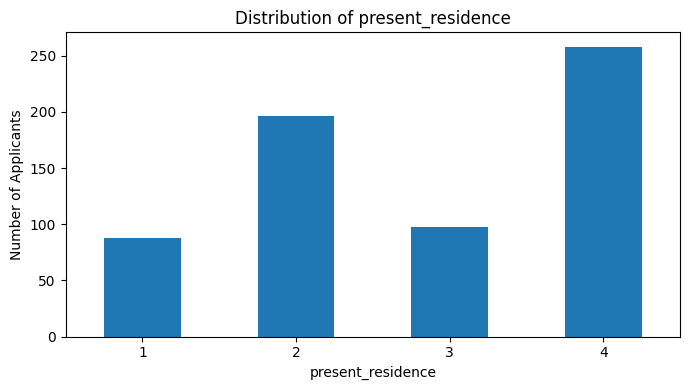

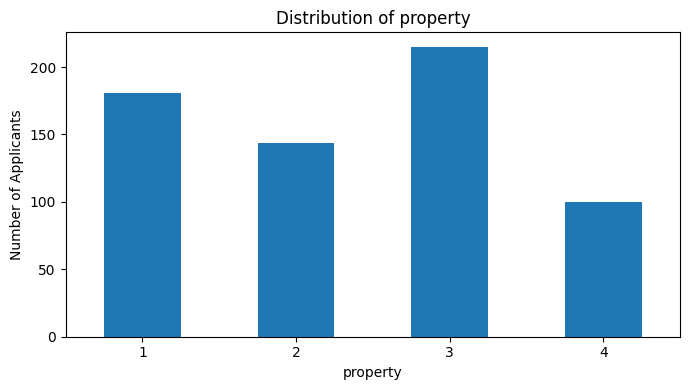

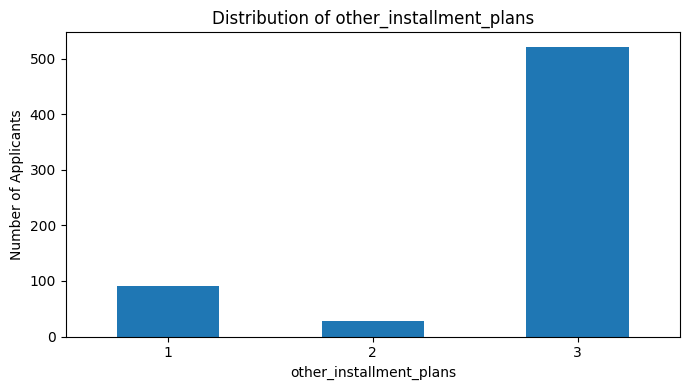

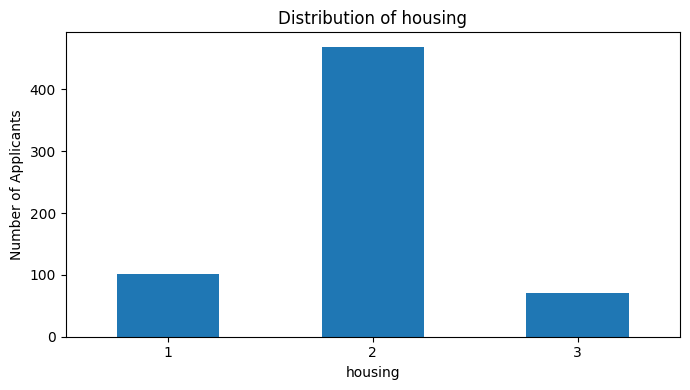

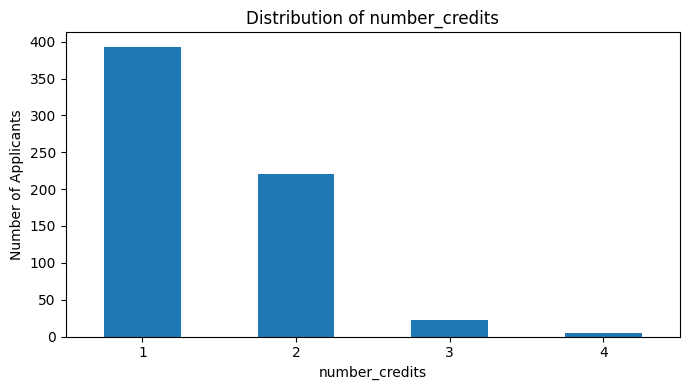

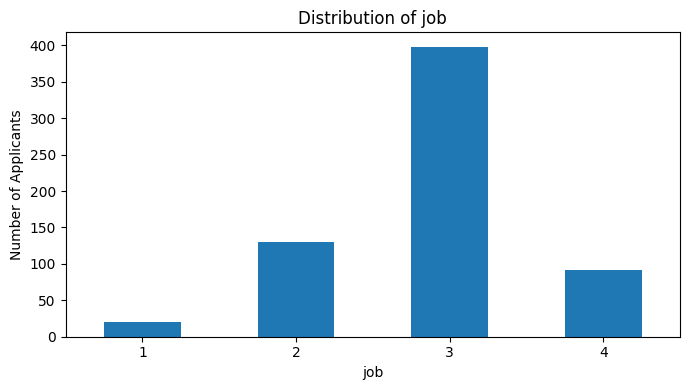

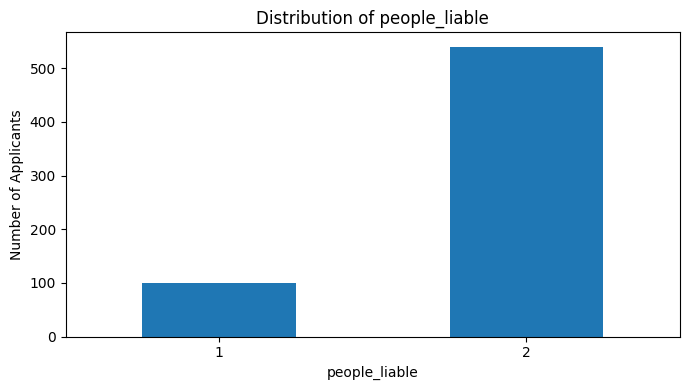

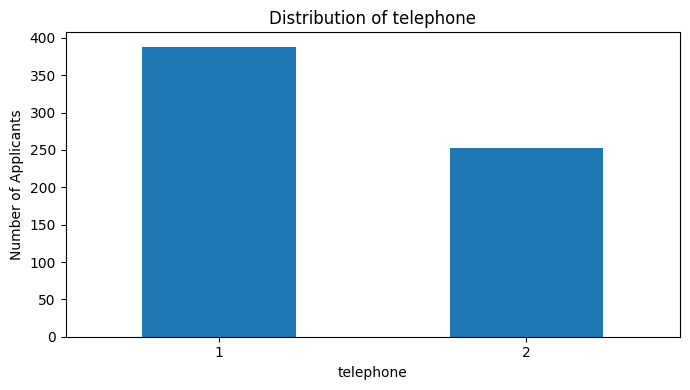

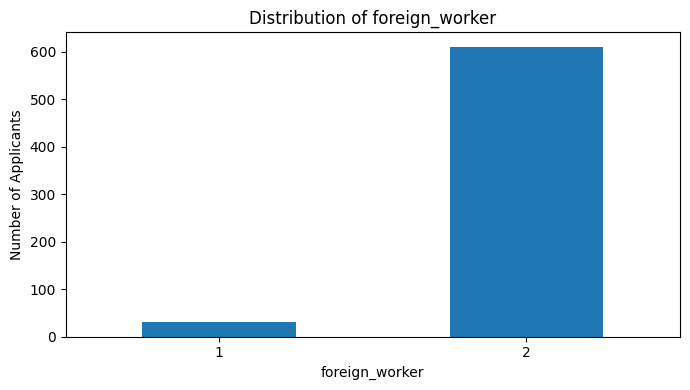

In [27]:
for feature in categorical_features:

    counts = (
        development[feature]
        .value_counts()
        .sort_index()
    )

    plt.figure(figsize=(7, 4))

    counts.plot(
        kind="bar"
    )

    plt.title(
        f"Distribution of {feature}"
    )

    plt.xlabel(feature)
    plt.ylabel("Number of Applicants")
    plt.xticks(rotation=0)

    plt.tight_layout()
    plt.show()

### **4.4.4 Bad-Credit Rate by Category**

In [28]:
categorical_bad_rates = {}

for feature in categorical_features:

    bad_rate = (
        development
        .groupby(feature)["bad_credit"]
        .agg(["count", "mean"])
        .rename(
            columns={
                "count": "Applicants",
                "mean": "Bad_Credit_Rate"
            }
        )
    )

    bad_rate["Bad_Credit_Rate"] = (
        bad_rate["Bad_Credit_Rate"] * 100
    )

    categorical_bad_rates[feature] = bad_rate

    print(f"\n{feature}")
    display(bad_rate)


status


,Applicants,Bad_Credit_Rate
status,,
1,159,45.283019
2,179,34.636872
3,41,4.878049
4,261,9.195402



credit_history


,Applicants,Bad_Credit_Rate
credit_history,,
0,27,48.148148
1,33,54.545455
2,315,27.301587
3,55,23.636364
4,210,14.285714



purpose


,Applicants,Bad_Credit_Rate
purpose,,
0,154,33.116883
1,65,12.307692
2,111,24.324324
3,180,18.888889
4,6,16.666667
5,17,23.529412
6,35,42.857143
8,7,0.000000
9,56,28.571429



savings


,Applicants,Bad_Credit_Rate
savings,,
1,372,30.645161
2,74,28.378378
3,43,18.604651
4,31,6.451613
5,120,12.500000



employment_duration


,Applicants,Bad_Credit_Rate
employment_duration,,
1,42,35.714286
2,117,35.042735
3,199,25.125628
4,121,14.876033
5,161,22.360248



installment_rate


,Applicants,Bad_Credit_Rate
installment_rate,,
1,96,22.916667
2,145,20.000000
3,98,24.489796
4,301,28.239203



personal_status_sex


,Applicants,Bad_Credit_Rate
personal_status_sex,,
1,29,34.482759
2,198,30.303030
3,354,21.186441
4,59,25.423729



other_debtors


,Applicants,Bad_Credit_Rate
other_debtors,,
1,578,25.086505
2,32,31.250000
3,30,16.666667



present_residence


,Applicants,Bad_Credit_Rate
present_residence,,
1,88,22.727273
2,196,27.551020
3,98,21.428571
4,258,25.193798



property


,Applicants,Bad_Credit_Rate
property,,
1,181,18.232044
2,144,25.000000
3,215,26.046512
4,100,35.000000



other_installment_plans


,Applicants,Bad_Credit_Rate
other_installment_plans,,
1,91,34.065934
2,28,35.714286
3,521,22.840691



housing


,Applicants,Bad_Credit_Rate
housing,,
1,101,35.643564
2,469,21.321962
3,70,34.285714



number_credits


,Applicants,Bad_Credit_Rate
number_credits,,
1,393,26.208651
2,220,23.181818
3,22,22.727273
4,5,20.000000



job


,Applicants,Bad_Credit_Rate
job,,
1,20,30.000000
2,130,19.230769
3,398,24.874372
4,92,32.608696



people_liable


,Applicants,Bad_Credit_Rate
people_liable,,
1,100,18.000000
2,540,26.296296



telephone


,Applicants,Bad_Credit_Rate
telephone,,
1,388,26.288660
2,252,23.015873



foreign_worker


,Applicants,Bad_Credit_Rate
foreign_worker,,
1,30,10.000000
2,610,25.737705


### **4.4.5 Rare and Dominant Categories**

In [29]:
rare_dominant_summary = []

for feature in categorical_features:

    proportions = (
        development[feature]
        .value_counts(normalize=True)
    )

    rare_categories = (
        proportions[proportions < 0.05]
        .index
        .tolist()
    )

    dominant_percentage = (
        proportions.max() * 100
    )

    rare_dominant_summary.append({
        "Feature": feature,
        "Rare_Categories": rare_categories,
        "Number_of_Rare_Categories": len(rare_categories),
        "Dominant_Category_Percentage": round(
            dominant_percentage, 2
        )
    })

rare_dominant_summary = pd.DataFrame(
    rare_dominant_summary
)

# Show only potentially notable features
rare_dominant_summary[
    (rare_dominant_summary["Number_of_Rare_Categories"] > 0)
    |
    (rare_dominant_summary["Dominant_Category_Percentage"] >= 70)
]

,Feature,Rare_Categories,Number_of_Rare_Categories,Dominant_Category_Percentage
1,credit_history,[0],1,49.22
2,purpose,"[5, 10, 8, 4]",4,28.12
3,savings,[4],1,58.13
6,personal_status_sex,[1],1,55.31
7,other_debtors,[3],1,90.31
10,other_installment_plans,[2],1,81.41
11,housing,[],0,73.28
12,number_credits,"[3, 4]",2,61.41
13,job,[1],1,62.19
14,people_liable,[],0,84.38


### **Rare and Dominant Category Findings**

Several categorical predictors contain rare or highly dominant categories.

In particular, some variables are concentrated heavily in a single category, while others contain categories representing fewer than 5% of observations.

These patterns may indicate limited variability or unstable estimates for rare categories. However, no feature is removed based on this analysis alone.

These variables will be revisited during the later feature-importance and ablation analysis.

## **4.5 Feature–Target Relationship Analysis**

The exploratory analysis is extended by quantifying the relationship between each predictor and the target variable.

Different association measures are used for numerical and categorical variables:

- numerical predictors are evaluated using point-biserial correlation,
- categorical predictors are evaluated using Cramér's V.

These measures are used only as exploratory evidence.

They do not directly determine which features will be removed from the modelling pipeline.

### **4.5.1 Numerical Association with the Target**

In [30]:
from scipy.stats import (
    pointbiserialr,
    chi2_contingency
)

In [31]:
numerical_target_association = []

for feature in numeric_features:

    correlation, p_value = pointbiserialr(
        development["bad_credit"],
        development[feature]
    )

    numerical_target_association.append({
        "Feature": feature,
        "Point_Biserial_Correlation": correlation,
        "Absolute_Correlation": abs(correlation),
        "P_Value": p_value
    })

numerical_target_association = pd.DataFrame(
    numerical_target_association
)

numerical_target_association = (
    numerical_target_association
    .sort_values(
        "Absolute_Correlation",
        ascending=False
    )
    .reset_index(drop=True)
)

numerical_target_association

,Feature,Point_Biserial_Correlation,Absolute_Correlation,P_Value
0,duration,0.205667,0.205667,1.528927e-07
1,amount,0.146837,0.146837,1.932581e-04
2,age,-0.099812,0.099812,1.152255e-02


### **4.5.2 Categorical Association with the Target**

Cramér's V is used to summarize the strength of association between each categorical predictor and the binary credit-risk target.

Values closer to zero indicate weaker association, while larger values indicate stronger association.

Because this is exploratory analysis, Cramér's V is used as descriptive evidence rather than as an automatic feature-selection rule.

In [32]:
def cramers_v(feature, target):

    contingency_table = pd.crosstab(
        feature,
        target
    )

    chi2, _, _, _ = chi2_contingency(
        contingency_table
    )

    n = contingency_table.to_numpy().sum()

    rows, cols = contingency_table.shape

    phi2 = chi2 / n

    denominator = min(
        rows - 1,
        cols - 1
    )

    if denominator == 0:
        return 0

    return np.sqrt(
        phi2 / denominator
    )

In [33]:
categorical_target_association = []

for feature in categorical_features:

    association = cramers_v(
        development[feature],
        development["bad_credit"]
    )

    categorical_target_association.append({
        "Feature": feature,
        "Cramers_V": association
    })

categorical_target_association = pd.DataFrame(
    categorical_target_association
)

categorical_target_association = (
    categorical_target_association
    .sort_values(
        "Cramers_V",
        ascending=False
    )
    .reset_index(drop=True)
)

categorical_target_association

,Feature,Cramers_V
0,status,0.369494
1,credit_history,0.240056
2,purpose,0.198948
3,savings,0.191210
4,employment_duration,0.158505
5,housing,0.140896
6,property,0.124252
7,personal_status_sex,0.105415
8,other_installment_plans,0.104574
9,job,0.092011


### **4.5.3 Association Overview**

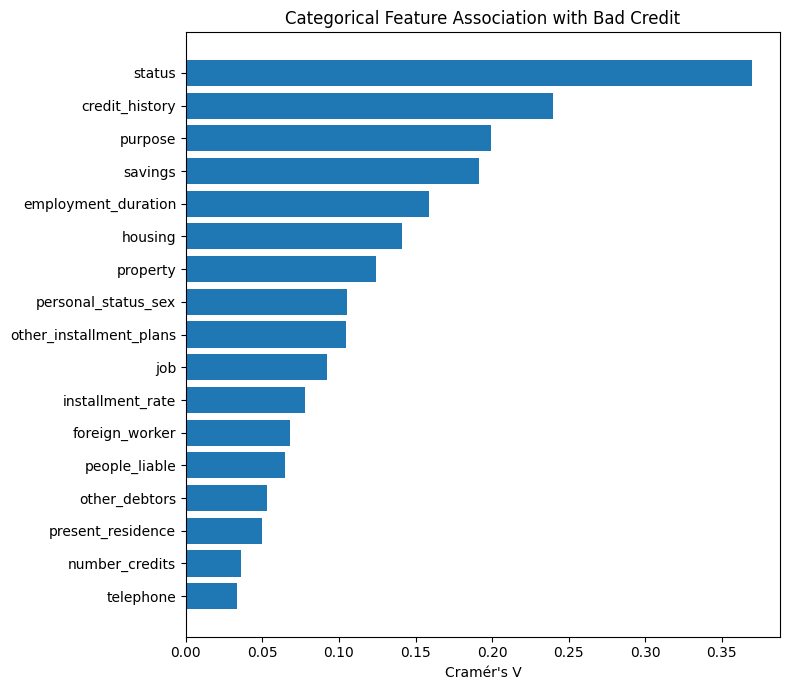

In [34]:
plot_data = (
    categorical_target_association
    .sort_values(
        "Cramers_V",
        ascending=True
    )
)

plt.figure(figsize=(8, 7))

plt.barh(
    plot_data["Feature"],
    plot_data["Cramers_V"]
)

plt.title(
    "Categorical Feature Association with Bad Credit"
)

plt.xlabel("Cramér's V")

plt.tight_layout()
plt.show()

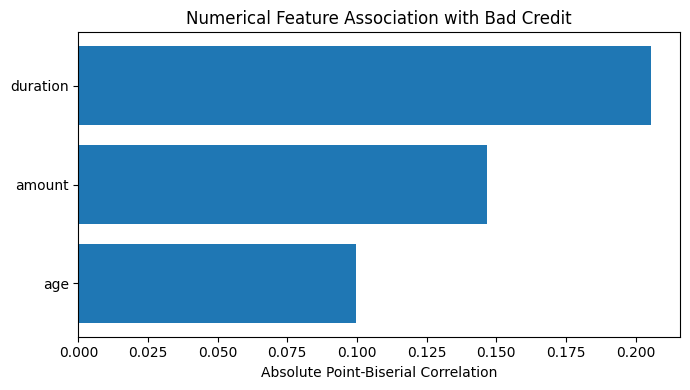

In [35]:
plot_data = (
    numerical_target_association
    .sort_values(
        "Absolute_Correlation",
        ascending=True
    )
)

plt.figure(figsize=(7, 4))

plt.barh(
    plot_data["Feature"],
    plot_data["Absolute_Correlation"]
)

plt.title(
    "Numerical Feature Association with Bad Credit"
)

plt.xlabel(
    "Absolute Point-Biserial Correlation"
)

plt.tight_layout()
plt.show()

### **4.5.4 Feature–Target Association Findings**

The feature–target association analysis reveals substantial differences in apparent predictive strength.

Among the numerical predictors:

- `duration` shows the strongest association with credit risk,
- `amount` shows a moderate association,
- and `age` shows a weaker but still noticeable relationship.

Among the categorical predictors, `status` exhibits the strongest association with `bad_credit`, followed by variables such as:

- `credit_history`,
- `purpose`,
- `savings`,
- and `employment_duration`.

Several variables, including `telephone`, `number_credits`, and `present_residence`, show relatively weak univariate associations with the target.

However, weak univariate association does not necessarily imply that a predictor is useless in a multivariate model.

Therefore, these results are treated as exploratory evidence only. No feature is removed at this stage.

## **4.6 Initial Feature Assessment**

The EDA suggests that predictors differ considerably in their apparent relationship with credit risk.

Some variables show stronger class separation or stronger statistical association with `bad_credit`, while others appear to contain weaker or less variable information.

However, exploratory association alone is not sufficient evidence for removing a predictor.

Several reasons justify retaining all predictors at this stage:

- a weak univariate relationship does not imply that a feature is useless in combination with other predictors,
- nonlinear models may exploit relationships that are not visible through simple association measures,
- rare categories may still contain valuable risk information,
- and removing predictors based directly on the full development target could introduce selection bias.

Therefore, the baseline modelling pipeline will initially retain all 20 predictors.

Formal feature reduction will be investigated later using feature importance and controlled ablation experiments evaluated under Nested Cross-Validation.

## **4.7 EDA Summary**

The exploratory analysis produced several important findings:

- The development dataset contains no missing values.
- The target consists of 75% Good-credit and 25% Bad-credit applicants, indicating moderate class imbalance.
- The three numerical predictors (`duration`, `amount`, and `age`) are right-skewed and show differences between the two credit-risk classes.
- Several categorical predictors show substantial variation in Bad-credit rates across categories.
- Some categorical variables contain rare or highly dominant categories.
- Feature–target association measures indicate that predictors differ considerably in their apparent discriminatory strength.

Despite these differences, no predictor is removed during EDA.

All 20 predictors will be retained for the baseline modelling pipeline. Feature reduction will be investigated later using model-based importance and controlled Nested-CV ablation experiments.

# **PART II — DATA PREPARATION**

This part prepares the development data for modelling.

The predictor and target variables are formally defined, numerical and categorical preprocessing pipelines are constructed, and the fixed cross-validation structure used throughout the project is established.

All preprocessing operations will later be fitted only on training data to prevent information leakage.

# **5. Feature and Target Definition**

The modelling variables are defined using the 640-row development dataset.

The identifier column `Id` is excluded because it uniquely identifies observations and does not represent applicant characteristics.

The target variable `bad_credit` is separated from the predictors.

## **5.1 Define X and y**

In [36]:
X = development.drop(
    columns=["Id", "bad_credit"]
).copy()

y = development[
    "bad_credit"
].copy()

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (640, 20)
y shape: (640,)


In [37]:
print(
    "Number of predictors:",
    X.shape[1]
)

print(
    "Target classes:",
    sorted(y.unique())
)

print(
    "\nTarget distribution:"
)

print(
    y.value_counts().sort_index()
)

Number of predictors: 20
Target classes: [np.int64(0), np.int64(1)]

Target distribution:
bad_credit
0    480
1    160
Name: count, dtype: int64


## **5.2 Numerical and Categorical Feature Groups**

The 20 predictors are divided into two preprocessing groups.

### Numerical predictors

- `duration`
- `amount`
- `age`

These variables represent quantitative measurements and will later be median-imputed and standardized.

### Categorical predictors

The remaining 17 predictors are integer-coded categorical variables.

Their numerical codes represent categories rather than continuous quantities and will therefore be processed using categorical preprocessing.

In [38]:
numeric_features = [
    "duration",
    "amount",
    "age"
]

categorical_features = [
    col for col in X.columns
    if col not in numeric_features
]

print(
    "Numerical features:",
    len(numeric_features)
)

print(
    "Categorical features:",
    len(categorical_features)
)

print(
    "Total predictors:",
    len(numeric_features)
    + len(categorical_features)
)

Numerical features: 3
Categorical features: 17
Total predictors: 20


In [39]:
print("\nNumerical:")
print(numeric_features)

print("\nCategorical:")
print(categorical_features)


Numerical:
['duration', 'amount', 'age']

Categorical:
['status', 'credit_history', 'purpose', 'savings', 'employment_duration', 'installment_rate', 'personal_status_sex', 'other_debtors', 'present_residence', 'property', 'other_installment_plans', 'housing', 'number_credits', 'job', 'people_liable', 'telephone', 'foreign_worker']


## **5.3 Final Feature Sanity Check**

Before constructing the preprocessing pipeline, the feature groups are checked to ensure that:

- every predictor belongs to exactly one preprocessing group,
- no predictor is omitted,
- and the identifier and target variables are excluded.

In [40]:
all_defined_features = (
    numeric_features
    + categorical_features
)

print(
    "All X columns included:",
    set(all_defined_features)
    == set(X.columns)
)

print(
    "Duplicate feature assignments:",
    len(all_defined_features)
    - len(set(all_defined_features))
)

print(
    "Id included:",
    "Id" in all_defined_features
)

print(
    "Target included:",
    "bad_credit" in all_defined_features
)

All X columns included: True
Duplicate feature assignments: 0
Id included: False
Target included: False


# **6. Preprocessing Pipeline**

Different preprocessing strategies are required for numerical and categorical predictors.

The preprocessing pipeline is designed so that all data transformations can later be fitted only on training folds during Cross-Validation.

This is important for preventing information leakage.

The preprocessing strategy is:

- numerical predictors → median imputation + standardization,
- categorical predictors → most-frequent imputation + one-hot encoding.

## **6.1 Numerical Pipeline**

The numerical predictors are:

- `duration`
- `amount`
- `age`

Two preprocessing steps are applied.

### Median Imputation

Missing numerical values, if present in future training folds or external datasets, are replaced using the median calculated from the corresponding training data.

Although the current development dataset contains no missing values, the imputation step is retained to make the modelling pipeline robust and consistent.

### Standardization

Numerical variables are standardized using:

\[
z = \frac{x-\mu}{\sigma}
\]

where:

- \(x\) is the original value,
- \(\mu\) is the training-set mean,
- \(\sigma\) is the training-set standard deviation.

Standardization places numerical variables on comparable scales and is particularly important for models such as Logistic Regression, KNN, and SVM.

In [41]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import (
    StandardScaler,
    OneHotEncoder
)

**Numerical pipeline**

In [42]:
numeric_pipeline = Pipeline([
    (
        "imputer",
        SimpleImputer(
            strategy="median"
        )
    ),
    (
        "scaler",
        StandardScaler()
    )
])

numeric_pipeline

,steps,"[('imputer', ...), ('scaler', ...)]"
,transform_input,None
,memory,None
,verbose,False
,missing_values,nan
,strategy,'median'
,fill_value,None
,copy,True
,add_indicator,False
,keep_empty_features,False
,copy,True


## **6.2 Categorical Pipeline**

The remaining 17 predictors are categorical variables represented by integer codes.

Two preprocessing steps are applied.

### Most-Frequent Imputation

Missing categorical values, if present, are replaced using the most frequent category observed in the training data.

### One-Hot Encoding

Each categorical variable is converted into binary indicator columns.

`handle_unknown="ignore"` ensures that a category appearing in validation, benchmark, or competition data but not in the corresponding training data does not cause an error.

In [43]:
categorical_pipeline = Pipeline([
    (
        "imputer",
        SimpleImputer(
            strategy="most_frequent"
        )
    ),
    (
        "encoder",
        OneHotEncoder(
            handle_unknown="ignore",
            sparse_output=False
        )
    )
])

categorical_pipeline

,steps,"[('imputer', ...), ('encoder', ...)]"
,transform_input,None
,memory,None
,verbose,False
,missing_values,nan
,strategy,'most_frequent'
,fill_value,None
,copy,True
,add_indicator,False
,keep_empty_features,False
,categories,'auto'


## **6.3 Combined Preprocessing Transformer**

The numerical and categorical pipelines are combined using a `ColumnTransformer`.

This allows each group of predictors to receive the appropriate preprocessing steps within a single modelling pipeline.

In [44]:
preprocessor = ColumnTransformer([
    (
        "num",
        numeric_pipeline,
        numeric_features
    ),
    (
        "cat",
        categorical_pipeline,
        categorical_features
    )
])

preprocessor

,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,missing_values,nan
,strategy,'median'
,fill_value,None


## **6.4 Leakage Prevention in Preprocessing**

The preprocessing transformer must be fitted only on the training portion of each Cross-Validation fold.

For example, inside one Inner-CV round:

```text
Inner Training
      ↓
fit preprocessing
      ↓
fit model

Inner Validation
      ↓
transform using preprocessing
learned from Inner Training
      ↓
predict

## **6.5 Preprocessing Configuration Check**

In [45]:
print("Numerical pipeline:")
print(numeric_pipeline)

print("\nCategorical pipeline:")
print(categorical_pipeline)

print("\nCombined preprocessor:")
print(preprocessor)

Numerical pipeline:
Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                ('scaler', StandardScaler())])

Categorical pipeline:
Pipeline(steps=[('imputer', SimpleImputer(strategy='most_frequent')),
                ('encoder',
                 OneHotEncoder(handle_unknown='ignore', sparse_output=False))])

Combined preprocessor:
ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['duration', 'amount', 'age']),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('encoder',
                                                  OneHotEnc

## **6.6 Preprocessing Summary**

The preprocessing strategy is now fixed for the baseline modelling pipeline.

- `duration`, `amount`, and `age` are median-imputed and standardized.
- The remaining 17 categorical predictors are most-frequent-imputed and one-hot encoded.
- Unknown categorical levels are ignored safely during transformation.
- All preprocessing steps will be fitted only on training folds.
- No preprocessing transformation is fitted globally before Cross-Validation.

This preprocessing design will be used consistently across all candidate models.

# **7. Fixed Cross-Validation Structure**

A fixed Nested Cross-Validation structure is used throughout the project.

The development dataset contains 640 observations.

The evaluation design consists of:

- 5 Outer folds for evaluating the model-selection procedure,
- 3 Inner folds within each Outer Training set for selecting the model configuration and classification threshold.

The same fold assignments will be reused across all candidate models to ensure a fair comparison.

The key principle is:

**Inner CV selects. Outer CV evaluates.**

## **7.1 Cross-Validation Settings**

Stratified splitting is used to preserve the proportion of Good-credit and Bad-credit applicants across folds.

All Cross-Validation settings are fixed before model training and will not be modified according to model performance.

In [46]:
from sklearn.model_selection import StratifiedKFold

OUTER_FOLDS = 5
INNER_FOLDS = 3

CV_RANDOM_STATE = 42

## **7.2 Create Fixed Outer and Inner Fold Assignments**

In [47]:
outer_cv = StratifiedKFold(
    n_splits=OUTER_FOLDS,
    shuffle=True,
    random_state=CV_RANDOM_STATE
)

fold_records = []

for outer_fold, (outer_train_idx, outer_val_idx) in enumerate(
    outer_cv.split(
        development,
        development["bad_credit"]
    ),
    start=1
):

    # Outer Training
    outer_train_data = (
        development
        .iloc[outer_train_idx]
        .copy()
    )

    # Outer Validation
    outer_val_data = (
        development
        .iloc[outer_val_idx]
        .copy()
    )

    # Inner CV is created ONLY
    # inside the current Outer Training set
    inner_cv = StratifiedKFold(
        n_splits=INNER_FOLDS,
        shuffle=True,
        random_state=CV_RANDOM_STATE
    )

    inner_fold_assignment = {}

    for inner_fold, (_, inner_val_idx) in enumerate(
        inner_cv.split(
            outer_train_data,
            outer_train_data["bad_credit"]
        ),
        start=1
    ):

        inner_val_ids = (
            outer_train_data
            .iloc[inner_val_idx]["Id"]
        )

        for applicant_id in inner_val_ids:
            inner_fold_assignment[applicant_id] = inner_fold

    # Store Outer Training rows
    for applicant_id in outer_train_data["Id"]:

        fold_records.append({
            "Id": applicant_id,
            "outer_fold": outer_fold,
            "outer_role": "training",
            "inner_validation_fold":
                inner_fold_assignment[applicant_id]
        })

    # Store Outer Validation rows
    for applicant_id in outer_val_data["Id"]:

        fold_records.append({
            "Id": applicant_id,
            "outer_fold": outer_fold,
            "outer_role": "validation",
            "inner_validation_fold": pd.NA
        })

In [48]:
nested_folds = pd.DataFrame(
    fold_records
)

nested_folds["inner_validation_fold"] = (
    nested_folds["inner_validation_fold"]
    .astype("Int64")
)

nested_folds = (
    nested_folds
    .sort_values(
        ["outer_fold", "Id"]
    )
    .reset_index(drop=True)
)

nested_folds.head(10)

,Id,outer_fold,outer_role,inner_validation_fold
0,0,1,validation,<NA>
1,2,1,training,3
2,3,1,training,2
3,5,1,training,3
4,6,1,training,3
5,7,1,training,1
6,8,1,training,3
7,9,1,training,1
8,10,1,validation,<NA>
9,11,1,training,1


In [49]:
nested_folds.shape

(3200, 4)

## **7.3 Validate Outer Fold Structure**

The fixed Outer Cross-Validation assignments are checked to ensure that each fold contains the expected number of training and validation observations.

With 640 development observations and 5-fold Cross-Validation, each Outer iteration should contain:

- 512 Outer Training observations
- 128 Outer Validation observations

In [50]:
outer_fold_counts = (
    nested_folds
    .groupby(["outer_fold", "outer_role"])
    .size()
    .unstack()
)

outer_fold_counts

outer_role,training,validation
outer_fold,,
1,512,128
2,512,128
3,512,128
4,512,128
5,512,128


## **7.4 Cross-Validation Summary**

The development dataset is evaluated using a fixed 5×3 Nested Cross-Validation design.

- Outer CV: 5 folds, with 512 training and 128 validation observations per fold.
- Inner CV: 3 folds within each Outer Training set.
- Stratification preserves the Good/Bad class distribution.
- Inner CV is used for model and threshold selection.
- Outer CV is used to evaluate the selection procedure.

The same fixed fold assignments are reused across all candidate models.

# **8. Model Pipeline Demonstration**

Before running the full model search, one Logistic Regression model is used to demonstrate the complete prediction pipeline on Outer Fold 1.

This section is for illustration only. No model or threshold selection is performed here.

## **8.1 Select One Outer Fold**

In [51]:
# Use Outer Fold 1 only for demonstration
demo_fold = nested_folds[
    nested_folds["outer_fold"] == 1
]

train_ids = demo_fold.loc[
    demo_fold["outer_role"] == "training",
    "Id"
]

val_ids = demo_fold.loc[
    demo_fold["outer_role"] == "validation",
    "Id"
]

demo_train = development[
    development["Id"].isin(train_ids)
].copy()

demo_val = development[
    development["Id"].isin(val_ids)
].copy()

print("Training:", demo_train.shape[0])
print("Validation:", demo_val.shape[0])

Training: 512
Validation: 128


## **8.2 Fit an Example Logistic Regression Model**

The preprocessing pipeline and Logistic Regression are combined into one Pipeline.

All preprocessing parameters are learned only from the Outer Training data.

In [52]:
from sklearn.base import clone
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

X_demo_train = demo_train.drop(
    columns=["Id", "bad_credit"]
)

y_demo_train = demo_train["bad_credit"]

X_demo_val = demo_val.drop(
    columns=["Id", "bad_credit"]
)

y_demo_val = demo_val["bad_credit"]

In [53]:
demo_model = Pipeline([
    ("preprocessing", clone(preprocessor)),
    ("model", LogisticRegression(
        C=1.0,
        max_iter=1000,
        random_state=42
    ))
])

demo_model.fit(
    X_demo_train,
    y_demo_train
)

,steps,"[('preprocessing', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


## **8.3 Probability -> Threshold -> Prediction**

In [54]:
demo_prob = demo_model.predict_proba(
    X_demo_val
)[:, 1]

In [55]:
DEMO_THRESHOLD = 0.50

demo_pred = (
    demo_prob >= DEMO_THRESHOLD
).astype(int)
print(demo_pred)

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 1 0 1 0 0 1
 0 0 0 0 0 0 1 0 1 0 1 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0
 0 0 0 0 0 0 1 0 0 1 0 0 0 1 0 0 0 0 0 0 0 0 0 1 0 0 0 0 1 0 0 0 0 0 1 1 1
 0 0 0 0 1 0 0 1 0 0 0 0 0 1 1 0 0]


In [56]:
demo_predictions = pd.DataFrame({
    "Id": demo_val["Id"].values,
    "Actual": y_demo_val.values,
    "P(Bad)": demo_prob,
    "Prediction": demo_pred
})

demo_predictions.head(10)

,Id,Actual,P(Bad),Prediction
0,0,0,0.406851,0
1,10,0,0.480436,0
2,12,0,0.053951,0
3,21,0,0.173693,0
4,23,0,0.013765,0
5,24,0,0.090067,0
6,29,0,0.046971,0
7,35,0,0.348102,0
8,44,0,0.250628,0
9,48,0,0.171382,0


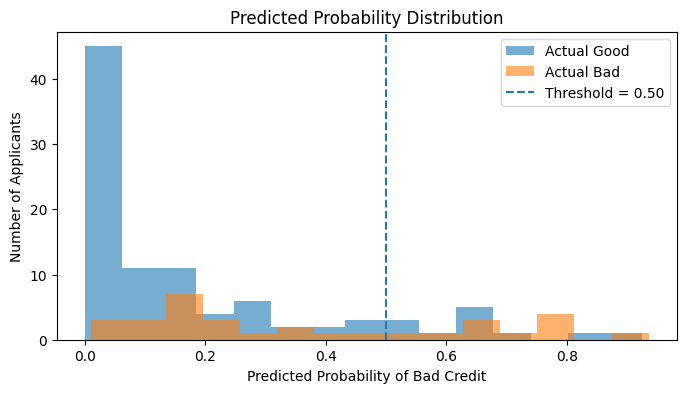

In [57]:
plt.figure(figsize=(8, 4))

plt.hist(
    demo_prob[y_demo_val.values == 0],
    bins=15,
    alpha=0.6,
    label="Actual Good"
)

plt.hist(
    demo_prob[y_demo_val.values == 1],
    bins=15,
    alpha=0.6,
    label="Actual Bad"
)

plt.axvline(
    DEMO_THRESHOLD,
    linestyle="--",
    label="Threshold = 0.50"
)

plt.xlabel("Predicted Probability of Bad Credit")
plt.ylabel("Number of Applicants")
plt.title("Predicted Probability Distribution")
plt.legend()

plt.show()

## **8.4 Demo Model Evaluation**

The demonstration model is evaluated on the 128 Outer Validation observations.

The evaluation includes the confusion matrix, business cost, classification metrics, and probability-based metrics.

The threshold of 0.50 is used only for demonstration and is not an optimized threshold.

In [58]:
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    roc_auc_score,
    average_precision_score,
    brier_score_loss
)

In [59]:
tn, fp, fn, tp = confusion_matrix(
    y_demo_val,
    demo_pred
).ravel()

confusion_table = pd.DataFrame(
    [
        [f"TN: {tn}",f"FP: {fp}"],
        [f"FN: {fn}",f"TP: {tp}"]
    ],
    index=[
        "Actual Good (0)",
        "Actual Bad (1)"
    ],
    columns=[
        "Predicted Good (0)",
        "Predicted Bad (1)"
    ]
)

confusion_table

,Predicted Good (0),Predicted Bad (1)
Actual Good (0),TN: 86,FP: 10
Actual Bad (1),FN: 21,TP: 11


In [60]:
demo_cost = 5 * fn + fp

print("False Positives :", fp)
print("False Negatives :", fn)
print("Business Cost   :", demo_cost)

False Positives : 10
False Negatives : 21
Business Cost   : 115


In [61]:
demo_metrics = pd.DataFrame({
    "Metric": [
        "Threshold",
        "TN",
        "FP",
        "FN",
        "TP",
        "Cost",
        "Accuracy",
        "Precision Bad",
        "Recall Bad",
        "ROC-AUC",
        "Average Precision",
        "Brier Score"
    ],

    "Value": [
        DEMO_THRESHOLD,
        tn,
        fp,
        fn,
        tp,
        demo_cost,

        accuracy_score(
            y_demo_val,
            demo_pred
        ),

        precision_score(
            y_demo_val,
            demo_pred,
            zero_division=0
        ),

        recall_score(
            y_demo_val,
            demo_pred
        ),

        roc_auc_score(
            y_demo_val,
            demo_prob
        ),

        average_precision_score(
            y_demo_val,
            demo_prob
        ),

        brier_score_loss(
            y_demo_val,
            demo_prob
        )
    ]
})

demo_metrics

,Metric,Value
0,Threshold,0.500000
1,TN,86.000000
2,FP,10.000000
3,FN,21.000000
4,TP,11.000000
5,Cost,115.000000
6,Accuracy,0.757812
7,Precision Bad,0.523810
8,Recall Bad,0.343750
9,ROC-AUC,0.752604


## **8.5 Demonstration Summary**

The Logistic Regression example demonstrates the complete modelling workflow on one Outer fold.

- The model is trained only on the 512 Outer Training observations.
- The 128 Outer Validation observations are kept unseen during model fitting.
- The model outputs the predicted probability of Bad credit, \(P(\text{Bad})\).
- A threshold of 0.50 is used to convert probabilities into Good/Bad predictions.
- The confusion matrix separates predictions into TN, FP, FN, and TP.
- Business performance is evaluated using:

\[
\text{Cost} = 5 \times FN + FP
\]

Because False Negatives are penalized five times more heavily than False Positives, the default threshold of 0.50 is not necessarily the most suitable threshold for this problem.

Therefore, the next stages will systematically evaluate multiple model configurations and optimize the classification threshold using Nested Cross-Validation.

This section is only a demonstration and is not used to select the final model.

# **9. Candidate Model Space**

Nine classification model families are considered.

Each model is evaluated using a small predefined hyperparameter grid.  
A model configuration represents one specific model with one specific combination of hyperparameters.

In total, 37 candidate configurations are evaluated.

The grid is fixed before Nested Cross-Validation and is not modified based on validation performance.

## **9.1 Define Candidate Configurations**

In [62]:
from itertools import product

from models.dummy import build_dummy
from models.logistic import build_logistic
from models.gaussian_nb import build_gaussian_nb
from models.knn import build_knn
from models.decision_tree import build_decision_tree
from models.random_forest import build_random_forest
from models.extra_trees import build_extra_trees
from models.rbf_svm import build_rbf_svm
from models.gradient_boosting import build_gradient_boosting

In [63]:
model_candidates = [

    {
        "model_name": "Dummy",
        "model_builder": build_dummy,
        "configs": [
            {}
        ]
    },

    {
        "model_name": "Logistic Regression",
        "model_builder": build_logistic,
        "configs": [
            {
                "C": C,
                "class_weight": class_weight
            }
            for C, class_weight in product(
                [0.1, 1, 10],
                [None, "balanced"]
            )
        ]
    },

    {
        "model_name": "Gaussian Naive Bayes",
        "model_builder": build_gaussian_nb,
        "configs": [
            {"var_smoothing": value}
            for value in [1e-9, 1e-3]
        ]
    },

    {
        "model_name": "KNN",
        "model_builder": build_knn,
        "configs": [
            {
                "n_neighbors": n,
                "weights": weights
            }
            for n, weights in product(
                [5, 15, 31],
                ["uniform", "distance"]
            )
        ]
    },

    {
        "model_name": "Decision Tree",
        "model_builder": build_decision_tree,
        "configs": [
            {
                "max_depth": depth,
                "min_samples_leaf": leaf
            }
            for depth, leaf in product(
                [3, 6],
                [5, 15]
            )
        ]
    },

    {
        "model_name": "Random Forest",
        "model_builder": build_random_forest,
        "configs": [
            {
                "max_depth": depth,
                "min_samples_leaf": leaf
            }
            for depth, leaf in product(
                [5, None],
                [3, 10]
            )
        ]
    },

    {
        "model_name": "Extra Trees",
        "model_builder": build_extra_trees,
        "configs": [
            {
                "max_depth": depth,
                "min_samples_leaf": leaf
            }
            for depth, leaf in product(
                [5, None],
                [3, 10]
            )
        ]
    },

    {
        "model_name": "RBF SVM",
        "model_builder": build_rbf_svm,
        "configs": [
            {
                "C": C,
                "gamma": gamma
            }
            for C, gamma in product(
                [0.1, 1, 10],
                ["scale", 0.01]
            )
        ]
    },

    {
        "model_name": "Gradient Boosting",
        "model_builder": build_gradient_boosting,
        "configs": [
            {
                "learning_rate": learning_rate,
                "max_depth": depth
            }
            for learning_rate, depth in product(
                [0.05, 0.1],
                [1, 2]
            )
        ]
    }
]

## **9.2 Verify 37 Configurations**

In [64]:
candidate_summary = pd.DataFrame({
    "Model": [
        candidate["model_name"]
        for candidate in model_candidates
    ],
    "Configurations": [
        len(candidate["configs"])
        for candidate in model_candidates
    ]
})

candidate_summary


,Model,Configurations
0,Dummy,1
1,Logistic Regression,6
2,Gaussian Naive Bayes,2
3,KNN,6
4,Decision Tree,4
5,Random Forest,4
6,Extra Trees,4
7,RBF SVM,6
8,Gradient Boosting,4


In [65]:
total_configs = candidate_summary["Configurations"].sum()

print("Total configurations:", total_configs)

Total configurations: 37


### **Candidate Space Summary**

The candidate search space contains:

- 9 model families
- 37 predefined model configurations
- The same preprocessing pipeline and fixed Cross-Validation folds for all candidates

At this stage, only model type and hyperparameters are varied.

Feature selection is evaluated separately in a later stage.

The next step is to determine the classification threshold that minimizes the business cost:

\[
Cost = 5FN + FP
\]

# **10. Threshold Selection**

Each model produces a probability of Bad credit rather than a final class directly.

A classification threshold converts the predicted probability into a class:

- \(P(Bad) \geq threshold\) → Bad (1)
- \(P(Bad) < threshold\) → Good (0)

Because a False Negative is five times more costly than a False Positive, the default threshold of 0.50 may not minimize business cost.

The threshold is therefore selected using Inner Cross-Validation predictions only.

## **10.1 Business Cost Function**

In [66]:
def business_cost(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(
        y_true,
        y_pred
    ).ravel()

    cost = 5 * fn + fp

    return cost

## **10.2 Threshold Search**

In [67]:
THRESHOLDS = np.round(
    np.arange(0.01, 1.00, 0.01),
    2
)
print(THRESHOLDS[:10])

[0.01 0.02 0.03 0.04 0.05 0.06 0.07 0.08 0.09 0.1 ]


In [68]:
def find_best_threshold(
    y_true,
    prob_bad,
    thresholds=THRESHOLDS
):

    results = []

    for threshold in thresholds:

        y_pred = (
            prob_bad >= threshold
        ).astype(int)

        tn, fp, fn, tp = confusion_matrix(
            y_true,
            y_pred
        ).ravel()

        cost = 5 * fn + fp

        results.append({
            "Threshold": threshold,
            "TN": tn,
            "FP": fp,
            "FN": fn,
            "TP": tp,
            "Cost": cost
        })

    threshold_results = pd.DataFrame(results)

    best_result = (
        threshold_results
        .sort_values(
            ["Cost", "Threshold"]
        )
        .iloc[0]
    )

    return best_result, threshold_results

### **Threshold Selection Rule**

For each candidate model configuration:

1. Generate Inner OOF probabilities.
2. Test thresholds from 0.01 to 0.99.
3. Compute \(Cost = 5FN + FP\) at each threshold.
4. Select the threshold with the minimum cost.
5. If multiple thresholds have the same minimum cost, select the lower threshold.

Outer Validation labels are never used for threshold selection.

# **11. Nested Cross-Validation Walkthrough**

To illustrate the Nested Cross-Validation procedure, Outer Fold 1 is examined in detail.

One Logistic Regression configuration is first used to demonstrate how Inner Cross-Validation generates out-of-fold probabilities.

These Inner OOF probabilities are then used to select the classification threshold.

## **11.1 Prepare Outer Fold 1**

In [69]:
outer1 = nested_folds[
    nested_folds["outer_fold"] == 1
].copy()

outer1_train_ids = outer1.loc[
    outer1["outer_role"] == "training",
    "Id"
]

outer1_val_ids = outer1.loc[
    outer1["outer_role"] == "validation",
    "Id"
]

outer1_train = development[
    development["Id"].isin(outer1_train_ids)
].copy()

outer1_val = development[
    development["Id"].isin(outer1_val_ids)
].copy()

print("Outer Training:", len(outer1_train))
print("Outer Validation:", len(outer1_val))

Outer Training: 512
Outer Validation: 128


## **11.2 Generate Inner OOF Probabilities**

The 512 Outer Training observations are divided into three Inner folds.

For each Inner fold:

1. Train the pipeline on the other two folds.
2. Predict \(P(Bad)\) for the held-out Inner Validation fold.
3. Store these predictions as out-of-fold probabilities.

After all three Inner folds, every one of the 512 observations has exactly one OOF probability.

In [70]:
oof_prob = pd.Series(
    index=outer1_train.index,
    dtype=float
)

for inner_fold in [1, 2, 3]:

    # IDs used as validation in this Inner fold
    inner_val_ids = outer1.loc[
        outer1["inner_validation_fold"] == inner_fold,
        "Id"
    ]

    inner_val_mask = outer1_train["Id"].isin(
        inner_val_ids
    )

    inner_train = outer1_train[
        ~inner_val_mask
    ].copy()

    inner_val = outer1_train[
        inner_val_mask
    ].copy()

    # Training data
    X_inner_train = inner_train.drop(
        columns=["Id", "bad_credit"]
    )

    y_inner_train = inner_train["bad_credit"]

    # Validation data
    X_inner_val = inner_val.drop(
        columns=["Id", "bad_credit"]
    )

    # Fresh pipeline for each Inner fold
    model = build_logistic(
        clone(preprocessor),
        C=1.0,
        class_weight=None
    )

    model.fit(
        X_inner_train,
        y_inner_train
    )

    inner_prob = model.predict_proba(
        X_inner_val
    )[:, 1]

    # Store OOF probabilities
    oof_prob.loc[
        inner_val.index
    ] = inner_prob

    print(
        f"Inner Fold {inner_fold}: "
        f"Train = {len(inner_train)}, "
        f"Validation = {len(inner_val)}"
    )

Inner Fold 1: Train = 341, Validation = 171
Inner Fold 2: Train = 341, Validation = 171
Inner Fold 3: Train = 342, Validation = 170


In [71]:
print("OOF predictions:", oof_prob.notna().sum())
print("Missing OOF predictions:", oof_prob.isna().sum())

OOF predictions: 512
Missing OOF predictions: 0


In [72]:
inner_oof_demo = pd.DataFrame({
    "Id": outer1_train["Id"],
    "Actual": outer1_train["bad_credit"],
    "OOF_P(Bad)": oof_prob
})

inner_oof_demo.head(10)

,Id,Actual,OOF_P(Bad)
1,2,0,0.113120
2,3,0,0.322838
3,5,0,0.149600
4,6,0,0.064034
5,7,0,0.013484
6,8,0,0.021002
7,9,0,0.599286
9,11,0,0.389062
11,13,0,0.102199
12,17,0,0.152726


## **11.3 Select Threshold for One Configuration**

The 512 Inner OOF probabilities are used to evaluate multiple classification thresholds.

For each threshold:

1. Convert \(P(Bad)\) into Good/Bad predictions.
2. Calculate TN, FP, FN, and TP.
3. Compute the business cost:

\[
Cost = 5FN + FP
\]

The threshold with the lowest Inner OOF cost is selected for this model configuration.

In [73]:
best_threshold_result, threshold_table = find_best_threshold(
    y_true=outer1_train["bad_credit"],
    prob_bad=oof_prob
)

best_threshold_result

Threshold      0.16
TN           244.00
FP           140.00
FN            27.00
TP           101.00
Cost         275.00
Name: 15, dtype: float64

In [74]:
threshold_table.sort_values(
    ["Cost", "Threshold"]
).head(10)

,Threshold,TN,FP,FN,TP,Cost
15,0.16,244,140,27,101,275
13,0.14,226,158,24,104,278
6,0.07,159,225,11,117,280
16,0.17,253,131,30,98,281
12,0.13,221,163,24,104,283
5,0.06,140,244,8,120,284
11,0.12,209,175,22,106,285
14,0.15,234,150,27,101,285
21,0.22,279,105,36,92,285
9,0.10,192,192,19,109,287


## **11.4 Search All Candidate Configurations**

The same Inner Cross-Validation procedure is repeated for all 37 predefined model configurations.

For each configuration:

1. Generate 512 Inner OOF probabilities.
2. Search for the threshold that minimizes \(5FN + FP\).
3. Record the configuration, selected threshold, confusion-matrix components, and Inner OOF cost.

The configuration with the lowest Inner OOF cost becomes the candidate selected for this Outer fold.

### **Helper: Create Inner OOF Probabilities**

In [75]:
def generate_inner_oof(
    model_builder,
    model_params,
    outer_train_data,
    outer_assignments
):

    oof_prob = pd.Series(
        index=outer_train_data.index,
        dtype=float
    )

    for inner_fold in [1, 2, 3]:

        inner_val_ids = outer_assignments.loc[
            outer_assignments["inner_validation_fold"] == inner_fold,
            "Id"
        ]

        val_mask = outer_train_data["Id"].isin(
            inner_val_ids
        )

        inner_train = outer_train_data[
            ~val_mask
        ]

        inner_val = outer_train_data[
            val_mask
        ]

        X_train = inner_train.drop(
            columns=["Id", "bad_credit"]
        )

        y_train = inner_train["bad_credit"]

        X_val = inner_val.drop(
            columns=["Id", "bad_credit"]
        )

        model = model_builder(
            clone(preprocessor),
            **model_params
        )

        model.fit(
            X_train,
            y_train
        )

        prob_bad = model.predict_proba(
            X_val
        )[:, 1]

        oof_prob.loc[
            inner_val.index
        ] = prob_bad

    return oof_prob

Run all 37 Configs

In [76]:
search_results = []

for candidate in model_candidates:

    model_name = candidate["model_name"]
    model_builder = candidate["model_builder"]

    for config in candidate["configs"]:

        # 1. Generate 512 Inner OOF probabilities
        config_oof = generate_inner_oof(
            model_builder=model_builder,
            model_params=config,
            outer_train_data=outer1_train,
            outer_assignments=outer1
        )

        # 2. Find best threshold
        best_threshold, _ = find_best_threshold(
            y_true=outer1_train["bad_credit"],
            prob_bad=config_oof
        )

        # 3. Save result
        search_results.append({
            "Model": model_name,
            "Params": config,
            "Threshold": best_threshold["Threshold"],
            "TN": int(best_threshold["TN"]),
            "FP": int(best_threshold["FP"]),
            "FN": int(best_threshold["FN"]),
            "TP": int(best_threshold["TP"]),
            "Cost": int(best_threshold["Cost"])
        })

In [77]:
inner_search_results = pd.DataFrame(
    search_results
)

inner_search_results = (
    inner_search_results
    .sort_values(
        ["Cost", "Threshold"]
    )
    .reset_index(drop=True)
)

inner_search_results.head(10)

,Model,Params,Threshold,TN,FP,FN,TP,Cost
0,RBF SVM,"{'C': 1, 'gamma': 0.01}",0.20,239,145,22,106,255
1,RBF SVM,"{'C': 0.1, 'gamma': 0.01}",0.19,230,154,21,107,259
2,RBF SVM,"{'C': 10, 'gamma': 0.01}",0.19,240,144,23,105,259
3,RBF SVM,"{'C': 0.1, 'gamma': 'scale'}",0.18,216,168,20,108,268
4,RBF SVM,"{'C': 1, 'gamma': 'scale'}",0.18,221,163,21,107,268
5,Decision Tree,"{'max_depth': 3, 'min_samples_leaf': 5}",0.07,177,207,13,115,272
6,Logistic Regression,"{'C': 1, 'class_weight': 'balanced'}",0.33,242,142,26,102,272
7,Logistic Regression,"{'C': 1, 'class_weight': None}",0.16,244,140,27,101,275
8,Logistic Regression,"{'C': 10, 'class_weight': None}",0.03,145,239,8,120,279
9,Logistic Regression,"{'C': 10, 'class_weight': 'balanced'}",0.22,227,157,25,103,282


In [78]:
print(
    "Configurations evaluated:",
    len(inner_search_results)
)

Configurations evaluated: 37


## **11.5 Select the Inner-CV Winner**

The candidate with the lowest Inner OOF business cost is selected for Outer Fold 1.

The selected rule consists of:

- the model family,
- the hyperparameter configuration,
- and the classification threshold.

This selection is based only on the 512 Outer Training observations.  
The 128 Outer Validation observations have not yet been used.

In [79]:
best_inner_result = inner_search_results.iloc[0]

best_inner_result

Model                        RBF SVM
Params       {'C': 1, 'gamma': 0.01}
Threshold                        0.2
TN                               239
FP                               145
FN                                22
TP                               106
Cost                             255
Name: 0, dtype: object

In [80]:
best_model_name = best_inner_result["Model"]
best_params = best_inner_result["Params"]
best_threshold = best_inner_result["Threshold"]

print("Selected model:", best_model_name)
print("Selected params:", best_params)
print("Selected threshold:", best_threshold)
print("Inner OOF cost:", best_inner_result["Cost"])

Selected model: RBF SVM
Selected params: {'C': 1, 'gamma': 0.01}
Selected threshold: 0.2
Inner OOF cost: 255


## **11.6 Refit the Winner and Evaluate Outer Validation**

The configuration selected by Inner Cross-Validation is refitted on all 512 Outer Training observations.

The selected threshold is then applied unchanged to the 128 Outer Validation observations.

The Outer Validation set is used only for evaluation and does not influence model or threshold selection.

This provides an unbiased evaluation of the complete selection procedure for Outer Fold 1.

# **12. Full 5 Fold Nested Cross Validation**

## **12.1 Get Data for One Outer Fold**

In [81]:
def get_outer_data(
    development,
    nested_folds,
    outer_fold
):

    assignment = nested_folds[
        nested_folds["outer_fold"] == outer_fold
    ]

    train_ids = assignment.loc[
        assignment["outer_role"] == "training",
        "Id"
    ]

    val_ids = assignment.loc[
        assignment["outer_role"] == "validation",
        "Id"
    ]
    

    outer_train = development[
        development["Id"].isin(train_ids)
    ].copy()

    outer_val = development[
        development["Id"].isin(val_ids)
    ].copy()

    return assignment, outer_train, outer_val

## **12.2 Search 37 Configurations in One Outer Fold**

In [82]:
def search_outer_candidates(
    outer_train,
    outer_assignment
):

    results = []

    for candidate in model_candidates:

        model_name = candidate["model_name"]
        model_builder = candidate["model_builder"]

        for config in candidate["configs"]:

            oof_prob = generate_inner_oof(
                model_builder=model_builder,
                model_params=config,
                outer_train_data=outer_train,
                outer_assignments=outer_assignment
            )

            best_threshold, _ = find_best_threshold(
                y_true=outer_train["bad_credit"],
                prob_bad=oof_prob
            )

            results.append({
                "Model": model_name,
                "Params": config,
                "Threshold": best_threshold["Threshold"],
                "Cost": int(best_threshold["Cost"])
            })

    results = pd.DataFrame(results)

    return (
        results
        .sort_values(["Cost", "Threshold"])
        .reset_index(drop=True)
    )

## **12.3 Evaluates the Winner on Outer Validation**

In [83]:
def evaluate_outer_winner(
    outer_fold,
    outer_train,
    outer_val,
    search_results
):

    winner = search_results.iloc[0]

    model_name = winner["Model"]
    params = winner["Params"]
    threshold = winner["Threshold"]

    selected_candidate = next(
        candidate
        for candidate in model_candidates
        if candidate["model_name"] == model_name
    )

    model_builder = selected_candidate[
        "model_builder"
    ]

    X_train = outer_train.drop(
        columns=["Id", "bad_credit"]
    )

    y_train = outer_train["bad_credit"]

    X_val = outer_val.drop(
        columns=["Id", "bad_credit"]
    )

    y_val = outer_val["bad_credit"]

    model = model_builder(
        clone(preprocessor),
        **params
    )

    model.fit(
        X_train,
        y_train
    )

    prob_bad = model.predict_proba(
        X_val
    )[:, 1]

    prediction = (
        prob_bad >= threshold
    ).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_val,
        prediction
    ).ravel()

    cost = 5 * fn + fp

    result = {
        "Outer Fold": outer_fold,
        "Selected Model": model_name,
        "Params": params,
        "Threshold": threshold,
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp,
        "Cost": cost,

        "Accuracy": accuracy_score(
            y_val,
            prediction
        ),

        "Precision Bad": precision_score(
            y_val,
            prediction,
            zero_division=0
        ),

        "Recall Bad": recall_score(
            y_val,
            prediction
        ),

        "ROC-AUC": roc_auc_score(
            y_val,
            prob_bad
        ),

        "Average Precision": average_precision_score(
            y_val,
            prob_bad
        ),

        "Brier Score": brier_score_loss(
            y_val,
            prob_bad
        )
    }

    predictions = pd.DataFrame({
        "Id": outer_val["Id"].values,
        "Outer Fold": outer_fold,
        "Actual": y_val.values,
        "P(Bad)": prob_bad,
        "Prediction": prediction
    })

    return result, predictions    

## **12.4 Run All 5 Outer Folds**

In [84]:
outer_results_list = []
outer_predictions_list = []

for outer_fold in [1, 2, 3, 4, 5]:

    print(f"Running Outer Fold {outer_fold}...")

    outer_assignment, outer_train, outer_val = get_outer_data(
        development,
        nested_folds,
        outer_fold
    )

    search_results = search_outer_candidates(
        outer_train,
        outer_assignment
    )

    result, predictions = evaluate_outer_winner(
        outer_fold,
        outer_train,
        outer_val,
        search_results
    )

    outer_results_list.append(
        result
    )

    outer_predictions_list.append(
        predictions
    )

Running Outer Fold 1...
Running Outer Fold 2...
Running Outer Fold 3...
Running Outer Fold 4...
Running Outer Fold 5...


In [85]:
outer_results = pd.DataFrame(
    outer_results_list
)

outer_predictions = pd.concat(
    outer_predictions_list,
    ignore_index=True
)

outer_results

,Outer Fold,Selected Model,Params,Threshold,TN,FP,FN,TP,Cost,Accuracy,Precision Bad,Recall Bad,ROC-AUC,Average Precision,Brier Score
0,1,RBF SVM,"{'C': 1, 'gamma': 0.01}",0.20,63,33,13,19,98,0.640625,0.365385,0.59375,0.717122,0.425613,0.176433
1,2,Gradient Boosting,"{'learning_rate': 0.05, 'max_depth': 1}",0.22,53,43,3,29,58,0.640625,0.402778,0.90625,0.777669,0.479433,0.160317
2,3,Logistic Regression,"{'C': 0.1, 'class_weight': None}",0.22,65,31,6,26,61,0.710938,0.456140,0.81250,0.873047,0.721563,0.129177
3,4,Logistic Regression,"{'C': 10, 'class_weight': None}",0.07,47,49,7,25,84,0.562500,0.337838,0.78125,0.733073,0.600884,0.156311
4,5,Gradient Boosting,"{'learning_rate': 0.05, 'max_depth': 2}",0.21,51,45,9,23,90,0.578125,0.338235,0.71875,0.712402,0.495609,0.169490


In [86]:
outer_predictions.shape

(640, 5)

## **12.5 Overall Nested-CV Performance**

In [87]:
y_outer_true = outer_predictions["Actual"]
y_outer_pred = outer_predictions["Prediction"]
y_outer_prob = outer_predictions["P(Bad)"]

tn, fp, fn, tp = confusion_matrix(
    y_outer_true,
    y_outer_pred
).ravel()

total_cost = 5 * fn + fp

nested_metrics = pd.DataFrame({
    "Metric": [
        "TN",
        "FP",
        "FN",
        "TP",
        "Total Cost",
        "Accuracy",
        "Precision Bad",
        "Recall Bad",
        "ROC-AUC",
        "Average Precision",
        "Brier Score"
    ],
    "Value": [
        tn,
        fp,
        fn,
        tp,
        total_cost,
        accuracy_score(y_outer_true, y_outer_pred),
        precision_score(
            y_outer_true,
            y_outer_pred,
            zero_division=0
        ),
        recall_score(
            y_outer_true,
            y_outer_pred
        ),
        roc_auc_score(
            y_outer_true,
            y_outer_prob
        ),
        average_precision_score(
            y_outer_true,
            y_outer_prob
        ),
        brier_score_loss(
            y_outer_true,
            y_outer_prob
        )
    ]
})

nested_metrics

,Metric,Value
0,TN,279.000000
1,FP,201.000000
2,FN,38.000000
3,TP,122.000000
4,Total Cost,391.000000
5,Accuracy,0.626563
6,Precision Bad,0.377709
7,Recall Bad,0.762500
8,ROC-AUC,0.744954
9,Average Precision,0.521095


In [88]:
nested_confusion = pd.DataFrame(
    [
        [tn, fp],
        [fn, tp]
    ],
    index=[
        "Actual Good",
        "Actual Bad"
    ],
    columns=[
        "Predicted Good",
        "Predicted Bad"
    ]
)

nested_confusion

,Predicted Good,Predicted Bad
Actual Good,279,201
Actual Bad,38,122


## **12.6 Nested-CV Interpretation**

The 5 Outer folds produced costs of **98, 58, 61, 84, and 90**, giving a total Outer cost of **391**.

These results evaluate the **model-selection procedure**, not a single fixed model.

Key observations:

- The Outer cost varies across folds, indicating that performance depends somewhat on the training sample.
- Different model families are selected in different folds, suggesting some instability in model selection.
- The procedure generally accepts more False Positives in order to reduce costly False Negatives, which is consistent with the objective:

\[
Cost = 5FN + FP
\]

Therefore, the Nested-CV results are used as a baseline for evaluating the robustness of the selection procedure and for comparison with later feature-selection experiments.

The final model will be selected separately after the evaluation stage.

# **13. Full-Feature Selection Reference**

This section applies the model-selection procedure to the full 640-row development set using all 20 input features.

Its purpose is to provide a full-feature reference before introducing feature selection.

The selected configuration in this section is not treated as the final project model, because feature-set selection will be incorporated in the next stage.

## **13.1 Create Cross-Validation Folds for Full-Feature Selection**

A 3-fold stratified Cross-Validation structure is created on the full 640-row development set.

All 20 input features are retained at this stage.

Each of the 37 candidate model configurations is evaluated using the same folds. The resulting OOF probabilities are used to compare model configurations and thresholds under the full-feature setting.

In [89]:
FINAL_FOLDS = 3

final_cv = StratifiedKFold(
    n_splits=FINAL_FOLDS,
    shuffle=True,
    random_state=CV_RANDOM_STATE
)

## **13.2 Generate Full-Feature OOF Probabilities**

For each candidate configuration, 3-fold Cross-Validation is used to generate one OOF probability for every development observation.

Each observation is predicted by a model that was not trained on that observation.

At this stage, all 20 input features are used.

These OOF probabilities are used to optimize the classification threshold and calculate the selection cost.

In [90]:
def generate_final_oof(
    model_builder,
    model_params
):

    oof_prob = pd.Series(
        index=development.index,
        dtype=float
    )

    for train_idx, val_idx in final_cv.split(X, y):

        X_train = X.iloc[train_idx]
        y_train = y.iloc[train_idx]

        X_val = X.iloc[val_idx]

        model = model_builder(
            clone(preprocessor),
            **model_params
        )

        model.fit(
            X_train,
            y_train
        )

        prob_bad = model.predict_proba(
            X_val
        )[:, 1]

        oof_prob.iloc[val_idx] = prob_bad

    return oof_prob

In [91]:
test_oof = generate_final_oof(
    model_builder=build_logistic,
    model_params={
        "C": 1.0,
        "class_weight": None
    }
)

print("OOF predictions:", test_oof.notna().sum())

OOF predictions: 640


## **13.3 Search All Full-Feature Model Configurations**
All 37 predefined model configurations are evaluated using the same 3-fold Cross-Validation structure and the complete 20-feature input set.

For each configuration:

1. Generate 640 OOF probabilities.
2. Find the threshold that minimizes the business cost.
3. Store the selected threshold and corresponding confusion-matrix results.

The results provide a reference for model selection before feature-set selection is introduced.

In [92]:
final_search_results = []

for candidate in model_candidates:

    model_name = candidate["model_name"]
    model_builder = candidate["model_builder"]

    for config in candidate["configs"]:

        # 1. Generate 640 OOF probabilities
        final_oof = generate_final_oof(
            model_builder=model_builder,
            model_params=config
        )

        # 2. Find the best threshold
        best_threshold, _ = find_best_threshold(
            y_true=y,
            prob_bad=final_oof
        )

        # 3. Store the result
        final_search_results.append({
            "Model": model_name,
            "Params": config,
            "Threshold": best_threshold["Threshold"],
            "TN": int(best_threshold["TN"]),
            "FP": int(best_threshold["FP"]),
            "FN": int(best_threshold["FN"]),
            "TP": int(best_threshold["TP"]),
            "Cost": int(best_threshold["Cost"])
        })

In [93]:
final_search_results = (
    pd.DataFrame(final_search_results)
    .sort_values(
        ["Cost", "Threshold"]
    )
    .reset_index(drop=True)
)

final_search_results.head(10)

,Model,Params,Threshold,TN,FP,FN,TP,Cost
0,Logistic Regression,"{'C': 0.1, 'class_weight': 'balanced'}",0.37,266,214,23,137,329
1,Gradient Boosting,"{'learning_rate': 0.05, 'max_depth': 2}",0.18,265,215,24,136,335
2,Logistic Regression,"{'C': 1, 'class_weight': 'balanced'}",0.33,293,187,30,130,337
3,Logistic Regression,"{'C': 0.1, 'class_weight': None}",0.18,257,223,23,137,338
4,Gradient Boosting,"{'learning_rate': 0.1, 'max_depth': 1}",0.19,259,221,24,136,341
5,Random Forest,"{'max_depth': None, 'min_samples_leaf': 10}",0.23,259,221,24,136,341
6,Logistic Regression,"{'C': 1, 'class_weight': None}",0.09,223,257,17,143,342
7,Random Forest,"{'max_depth': 5, 'min_samples_leaf': 3}",0.21,243,237,21,139,342
8,Logistic Regression,"{'C': 10, 'class_weight': None}",0.08,242,238,21,139,343
9,Gradient Boosting,"{'learning_rate': 0.1, 'max_depth': 2}",0.15,262,218,25,135,343


In [94]:
print(
    "Configurations evaluated:",
    len(final_search_results)
)

Configurations evaluated: 37


## **13.4 Best Full-Feature Configuration**

The 37 full-feature candidate configurations are ranked by OOF business cost.

The configuration with the lowest cost is retained as the best reference configuration under the full 20-feature setting.

This result is not yet the final project rule because feature selection will be evaluated in the next stage.

In [95]:
final_winner = final_search_results.iloc[0]

final_model_name = final_winner["Model"]
final_params = final_winner["Params"]
final_threshold = final_winner["Threshold"]
final_selection_cost = final_winner["Cost"]

print("Final model:", final_model_name)
print("Final parameters:", final_params)
print("Final threshold:", final_threshold)
print("Final selection cost:", final_selection_cost)

Final model: Logistic Regression
Final parameters: {'C': 0.1, 'class_weight': 'balanced'}
Final threshold: 0.37
Final selection cost: 329


# **14. EDA-Based Feature Selection Strategy**

Feature selection is introduced as an additional component of the model-selection procedure.

Instead of selecting features after observing model performance, several feature sets are predefined based on exploratory data analysis (EDA).

The feature set itself is treated as a candidate choice during Inner CV.

The evaluated strategies are:

- Full_20: use all available features.
- Drop_2: remove two EDA-identified features.
- Drop_4: remove four EDA-identified features.
- Drop_6: remove six EDA-identified features.

The final feature strategy is selected together with the model configuration and classification threshold.

## **14.1 Define Dropped Features**

In [96]:
# All original features

ALL_FEATURES = list(X.columns)


DROP_2_FEATURES = [
    "telephone",
    "people_liable"
]


DROP_4_FEATURES = [
    "telephone",
    "people_liable",
    "other_debtors",
    "job"
]


DROP_6_FEATURES = [
    "telephone",
    "people_liable",
    "other_debtors",
    "job",
    "housing",
    "property"
]


## **14.2 Define Candidate Feature Sets**

In [97]:
FEATURE_SETS = {

    "Full_20": ALL_FEATURES,

    "Drop_2": [
        f for f in ALL_FEATURES
        if f not in DROP_2_FEATURES
    ],

    "Drop_4": [
        f for f in ALL_FEATURES
        if f not in DROP_4_FEATURES
    ],

    "Drop_6": [
        f for f in ALL_FEATURES
        if f not in DROP_6_FEATURES
    ]
}

In [98]:
for name, features in FEATURE_SETS.items():
    print(
        name,
        len(features),
        "features"
    )

Full_20 20 features
Drop_2 18 features
Drop_4 16 features
Drop_6 14 features


## **14.2 Feature Selection as Part of Model Selection**

The feature set is considered another model-selection choice.

Therefore, the Inner CV procedure evaluates:

- feature strategy,
- model family,
- hyperparameters,
- classification threshold.

The Outer Validation data is only used after the complete prediction rule has been selected.

This prevents the validation data from influencing feature selection decisions.

# **15. Nested CV with Feature Selection**

The Nested Cross-Validation procedure is extended to include feature-set selection.

For each Outer fold, the Inner CV evaluates all combinations of:

- 4 feature strategies,
- 37 model configurations,
- classification thresholds.

The winning rule is then evaluated on the untouched Outer Validation set.

## **15.1 Build Preprocessor for a Selected Feature Set**

Because the candidate feature sets contain different subsets of the original variables, the preprocessing pipeline must be rebuilt according to the selected features.

Numerical and categorical variables retain the same preprocessing rules used previously.

In [99]:
def build_feature_preprocessor(feature_set):

    selected_numeric = [
        feature
        for feature in numeric_features
        if feature in feature_set
    ]

    selected_categorical = [
        feature
        for feature in categorical_features
        if feature in feature_set
    ]

    numeric_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ])

    categorical_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        (
            "encoder",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            )
        )
    ])

    return ColumnTransformer([
        (
            "num",
            numeric_pipeline,
            selected_numeric
        ),
        (
            "cat",
            categorical_pipeline,
            selected_categorical
        )
    ])

## **15.2 Generate Inner OOF Predictions**

For each feature-set and model configuration, the fixed 3-fold Inner CV is used to generate OOF probabilities for the complete Outer Training set.

The selected feature set is applied consistently across the three Inner folds.

These OOF probabilities are then used to optimize the classification threshold and calculate the Inner-CV business cost.

In [100]:
def generate_inner_oof_feature_selection(
    model_builder,
    model_params,
    feature_set,
    outer_train,
    outer_assignment
):

    oof_prob = pd.Series(
        index=outer_train.index,
        dtype=float
    )

    for inner_fold in [1, 2, 3]:

        inner_val_ids = outer_assignment.loc[
            outer_assignment["inner_validation_fold"] == inner_fold,
            "Id"
        ]

        val_mask = outer_train["Id"].isin(
            inner_val_ids
        )

        inner_train = outer_train[
            ~val_mask
        ].copy()

        inner_val = outer_train[
            val_mask
        ].copy()

        X_inner_train = inner_train[
            feature_set
        ]

        y_inner_train = inner_train[
            "bad_credit"
        ]

        X_inner_val = inner_val[
            feature_set
        ]

        feature_preprocessor = build_feature_preprocessor(
            feature_set
        )

        model = model_builder(
            feature_preprocessor,
            **model_params
        )

        model.fit(
            X_inner_train,
            y_inner_train
        )

        prob_bad = model.predict_proba(
            X_inner_val
        )[:, 1]

        oof_prob.loc[
            inner_val.index
        ] = prob_bad

    return oof_prob

## **15.3 Search Feature Sets and Model Configurations**

Within each Outer Training set, the Inner CV evaluates all combinations of:

- 4 predefined feature sets,
- 37 model configurations,
- classification thresholds.

This produces 148 feature-set and model-configuration candidates.

For each candidate, the threshold with the lowest Inner-CV business cost is selected.

In [101]:
def search_outer_candidates_with_features(
    outer_train,
    outer_assignment
):

    results = []

    for feature_name, feature_set in FEATURE_SETS.items():

        for candidate in model_candidates:

            model_name = candidate["model_name"]
            model_builder = candidate["model_builder"]

            for config in candidate["configs"]:

                oof_prob = generate_inner_oof_feature_selection(
                    model_builder=model_builder,
                    model_params=config,
                    feature_set=feature_set,
                    outer_train=outer_train,
                    outer_assignment=outer_assignment
                )

                best_threshold, _ = find_best_threshold(
                    y_true=outer_train["bad_credit"],
                    prob_bad=oof_prob
                )

                results.append({
                    "Feature Set": feature_name,
                    "Number of Features": len(feature_set),
                    "Model": model_name,
                    "Params": config,
                    "Threshold": best_threshold["Threshold"],
                    "Cost": int(best_threshold["Cost"])
                })

    results = pd.DataFrame(results)

    results = (
        results
        .sort_values(
            [
                "Cost",
                "Threshold",
                "Number of Features"
            ]
        )
        .reset_index(drop=True)
    )

    return results

Test on Outer Fold 1

In [102]:
outer1_feature_search = search_outer_candidates_with_features(
    outer_train=outer1_train,
    outer_assignment=outer1
)

print(
    "Candidate combinations:",
    len(outer1_feature_search)
)

outer1_feature_search.head(10)

Candidate combinations: 148


,Feature Set,Number of Features,Model,Params,Threshold,Cost
0,Full_20,20,RBF SVM,"{'C': 1, 'gamma': 0.01}",0.20,255
1,Drop_2,18,RBF SVM,"{'C': 0.1, 'gamma': 'scale'}",0.18,256
2,Drop_6,14,Logistic Regression,"{'C': 10, 'class_weight': None}",0.17,257
3,Drop_6,14,Logistic Regression,"{'C': 1, 'class_weight': None}",0.13,259
4,Full_20,20,RBF SVM,"{'C': 0.1, 'gamma': 0.01}",0.19,259
5,Full_20,20,RBF SVM,"{'C': 10, 'gamma': 0.01}",0.19,259
6,Drop_6,14,Logistic Regression,"{'C': 10, 'class_weight': 'balanced'}",0.26,259
7,Drop_6,14,RBF SVM,"{'C': 0.1, 'gamma': 0.01}",0.17,260
8,Drop_6,14,RBF SVM,"{'C': 1, 'gamma': 0.01}",0.17,261
9,Drop_2,18,RBF SVM,"{'C': 10, 'gamma': 0.01}",0.18,261


## **15.4 Refit and Evaluate the Outer Winner**

The lowest-cost Inner-CV candidate is selected as the winner for the current Outer fold.

The selected feature set, model configuration, and threshold are frozen.

A fresh model is then fitted on the complete Outer Training set and evaluated on the untouched Outer Validation set.

In [103]:
def evaluate_outer_winner_with_features(
    outer_fold,
    outer_train,
    outer_val,
    search_results
):

    winner = search_results.iloc[0]

    feature_name = winner["Feature Set"]
    model_name = winner["Model"]
    params = winner["Params"]
    threshold = winner["Threshold"]

    selected_features = FEATURE_SETS[
        feature_name
    ]

    selected_candidate = next(
        candidate
        for candidate in model_candidates
        if candidate["model_name"] == model_name
    )

    model_builder = selected_candidate[
        "model_builder"
    ]

    X_train = outer_train[
        selected_features
    ]

    y_train = outer_train[
        "bad_credit"
    ]

    X_val = outer_val[
        selected_features
    ]

    y_val = outer_val[
        "bad_credit"
    ]

    feature_preprocessor = build_feature_preprocessor(
        selected_features
    )

    model = model_builder(
        feature_preprocessor,
        **params
    )

    model.fit(
        X_train,
        y_train
    )

    prob_bad = model.predict_proba(
        X_val
    )[:, 1]

    prediction = (
        prob_bad >= threshold
    ).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_val,
        prediction
    ).ravel()

    cost = 5 * fn + fp

    result = {
        "Outer Fold": outer_fold,
        "Feature Set": feature_name,
        "Number of Features": len(selected_features),
        "Selected Model": model_name,
        "Params": params,
        "Threshold": threshold,
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp,
        "Cost": cost,
        "Accuracy": accuracy_score(
            y_val,
            prediction
        ),
        "Precision Bad": precision_score(
            y_val,
            prediction,
            zero_division=0
        ),
        "Recall Bad": recall_score(
            y_val,
            prediction
        ),
        "ROC-AUC": roc_auc_score(
            y_val,
            prob_bad
        ),
        "Average Precision": average_precision_score(
            y_val,
            prob_bad
        ),
        "Brier Score": brier_score_loss(
            y_val,
            prob_bad
        )
    }

    predictions = pd.DataFrame({
        "Id": outer_val["Id"].values,
        "Outer Fold": outer_fold,
        "Actual": y_val.values,
        "P(Bad)": prob_bad,
        "Prediction": prediction
    })

    return result, predictions

## **15.5 Run the Full Nested CV**

The complete feature-selection procedure is repeated across all five Outer folds.

Each Outer fold independently selects its feature set, model configuration, and threshold using only its Outer Training data.

The selected rule is then evaluated on the corresponding untouched Outer Validation fold.

In [104]:
feature_outer_results_list = []
feature_outer_predictions_list = []


for outer_fold in [1, 2, 3, 4, 5]:

    print(
        f"Running Outer Fold {outer_fold}..."
    )

    outer_assignment, outer_train, outer_val = get_outer_data(
        development,
        nested_folds,
        outer_fold
    )

    search_results = search_outer_candidates_with_features(
        outer_train=outer_train,
        outer_assignment=outer_assignment
    )

    result, predictions = evaluate_outer_winner_with_features(
        outer_fold=outer_fold,
        outer_train=outer_train,
        outer_val=outer_val,
        search_results=search_results
    )

    feature_outer_results_list.append(
        result
    )

    feature_outer_predictions_list.append(
        predictions
    )


feature_outer_results = pd.DataFrame(
    feature_outer_results_list
)


feature_outer_predictions = pd.concat(
    feature_outer_predictions_list,
    ignore_index=True
)

Running Outer Fold 1...
Running Outer Fold 2...
Running Outer Fold 3...
Running Outer Fold 4...
Running Outer Fold 5...


In [105]:
feature_outer_results[
    [
        "Outer Fold",
        "Feature Set",
        "Selected Model",
        "Threshold",
        "Cost"
    ]
]

,Outer Fold,Feature Set,Selected Model,Threshold,Cost
0,1,Full_20,RBF SVM,0.20,98
1,2,Drop_6,Logistic Regression,0.36,62
2,3,Drop_6,Logistic Regression,0.33,59
3,4,Full_20,Logistic Regression,0.07,84
4,5,Full_20,Gradient Boosting,0.21,90


## **15.6 Feature-Selection Nested-CV Summary**

The Outer-fold results evaluate the complete selection procedure in which the feature set, model configuration, and threshold are selected jointly.

The resulting Outer performance can be compared with the Full-20 baseline Nested CV from Section 12.

In [106]:
feature_total_outer_cost = (
    feature_outer_results["Cost"].sum()
)

print(
    "Feature-selection Nested-CV Cost:",
    feature_total_outer_cost
)

print(
    "Full-20 Baseline Nested-CV Cost:",
    391
)

Feature-selection Nested-CV Cost: 393
Full-20 Baseline Nested-CV Cost: 391


# **16. Final Selection with Feature Sets**

After evaluating the complete feature-selection procedure using Nested Cross-Validation, the same selection rule is applied to the full 640-row development set.

The final search jointly selects:

- feature strategy,
- model family,
- hyperparameters,
- classification threshold.

The same predefined feature sets and 3-fold selection rule are retained.

## **16.1 Generate Final OOF Predictions**

For each feature-set and model-configuration candidate, 3-fold Cross-Validation is used to generate OOF probabilities for all 640 development observations.

These OOF probabilities are used only for final model selection.

In [107]:
def generate_final_oof_with_features(
    model_builder,
    model_params,
    feature_set
):

    oof_prob = pd.Series(
        index=development.index,
        dtype=float
    )

    for train_idx, val_idx in final_cv.split(X, y):

        X_train = X.iloc[train_idx][feature_set]
        y_train = y.iloc[train_idx]

        X_val = X.iloc[val_idx][feature_set]

        feature_preprocessor = build_feature_preprocessor(
            feature_set
        )

        model = model_builder(
            feature_preprocessor,
            **model_params
        )

        model.fit(
            X_train,
            y_train
        )

        prob_bad = model.predict_proba(
            X_val
        )[:, 1]

        oof_prob.iloc[val_idx] = prob_bad

    return oof_prob

## **16.2 Search All Final Candidates**

The final selection stage evaluates all combinations of:

- 4 predefined feature sets,
- 37 model configurations.

This produces 148 candidate combinations.

For each candidate, the threshold minimizing OOF business cost is selected.

In [108]:
final_feature_search_results = []


for feature_name, feature_set in FEATURE_SETS.items():

    for candidate in model_candidates:

        model_name = candidate["model_name"]
        model_builder = candidate["model_builder"]

        for config in candidate["configs"]:

            final_oof = generate_final_oof_with_features(
                model_builder=model_builder,
                model_params=config,
                feature_set=feature_set
            )

            best_threshold, _ = find_best_threshold(
                y_true=y,
                prob_bad=final_oof
            )

            final_feature_search_results.append({
                "Feature Set": feature_name,
                "Number of Features": len(feature_set),
                "Model": model_name,
                "Params": config,
                "Threshold": best_threshold["Threshold"],
                "TN": int(best_threshold["TN"]),
                "FP": int(best_threshold["FP"]),
                "FN": int(best_threshold["FN"]),
                "TP": int(best_threshold["TP"]),
                "Cost": int(best_threshold["Cost"])
            })

In [109]:
final_feature_search_results = (
    pd.DataFrame(final_feature_search_results)
    .sort_values(
        [
            "Cost",
            "Threshold",
            "Number of Features"
        ]
    )
    .reset_index(drop=True)
)

In [110]:
print(
    "Candidate combinations:",
    len(final_feature_search_results)
)

final_feature_search_results.head(10)

Candidate combinations: 148


,Feature Set,Number of Features,Model,Params,Threshold,TN,FP,FN,TP,Cost
0,Drop_6,14,Logistic Regression,"{'C': 0.1, 'class_weight': 'balanced'}",0.39,282,198,24,136,318
1,Drop_6,14,Logistic Regression,"{'C': 1, 'class_weight': None}",0.09,218,262,12,148,322
2,Drop_6,14,Logistic Regression,"{'C': 0.1, 'class_weight': None}",0.21,288,192,26,134,322
3,Drop_6,14,RBF SVM,"{'C': 10, 'gamma': 0.01}",0.15,237,243,16,144,323
4,Drop_6,14,Logistic Regression,"{'C': 1, 'class_weight': 'balanced'}",0.25,246,234,18,142,324
5,Drop_6,14,RBF SVM,"{'C': 0.1, 'gamma': 0.01}",0.24,344,136,38,122,326
6,Drop_6,14,RBF SVM,"{'C': 1, 'gamma': 0.01}",0.24,343,137,38,122,327
7,Drop_4,16,Logistic Regression,"{'C': 1, 'class_weight': 'balanced'}",0.26,252,228,20,140,328
8,Drop_2,18,Logistic Regression,"{'C': 1, 'class_weight': 'balanced'}",0.27,262,218,22,138,328
9,Drop_4,16,Logistic Regression,"{'C': 1, 'class_weight': None}",0.15,286,194,27,133,329


## **16.3 Select the Final Prediction Rule**

The candidate with the lowest OOF business cost is selected as the final prediction rule.

The final rule consists of:

- the selected feature set,
- model family,
- hyperparameters,
- classification threshold.

The OOF cost at this stage is a selection criterion and is not treated as an unbiased estimate of final model performance.

In [111]:
final_rule = final_feature_search_results.iloc[0]

final_feature_name = final_rule["Feature Set"]

final_features = FEATURE_SETS[
    final_feature_name
]

final_model_name = final_rule["Model"]

final_params = final_rule["Params"]

final_threshold = final_rule["Threshold"]

final_selection_cost = final_rule["Cost"]

In [112]:
print("Final feature set:", final_feature_name)
print("Number of features:", len(final_features))
print("Final model:", final_model_name)
print("Final parameters:", final_params)
print("Final threshold:", final_threshold)
print("Final selection cost:", final_selection_cost)

Final feature set: Drop_6
Number of features: 14
Final model: Logistic Regression
Final parameters: {'C': 0.1, 'class_weight': 'balanced'}
Final threshold: 0.39
Final selection cost: 318


# **17. Historical Benchmark Evaluation**

After the final prediction rule has been selected, a fresh model is fitted on all 640 development observations.

The selected feature set, model configuration, and classification threshold are kept fixed.

The historical benchmark is used only for diagnostic evaluation and does not influence model selection.

In [113]:
selected_candidate = next(
    candidate
    for candidate in model_candidates
    if candidate["model_name"] == final_model_name
)

final_model_builder = selected_candidate[
    "model_builder"
]


final_preprocessor = build_feature_preprocessor(
    final_features
)


final_model = final_model_builder(
    final_preprocessor,
    **final_params
)


X_development_final = development[
    final_features
]

y_development_final = development[
    "bad_credit"
]


final_model.fit(
    X_development_final,
    y_development_final
)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


## **17.1 Benchmark Prediction and Evaluation**

The fitted final model is applied to the 160-row historical benchmark.

The benchmark labels are used only to evaluate the already-frozen prediction rule.

No feature set, model parameter, or threshold is changed after observing these results.

In [114]:
X_benchmark = benchmark[
    final_features
]

y_benchmark = benchmark[
    "bad_credit"
]


benchmark_prob = final_model.predict_proba(
    X_benchmark
)[:, 1]


benchmark_pred = (
    benchmark_prob >= final_threshold
).astype(int)

In [115]:
tn, fp, fn, tp = confusion_matrix(
    y_benchmark,
    benchmark_pred
).ravel()


benchmark_cost = 5 * fn + fp

In [116]:
benchmark_metrics = pd.DataFrame({
    "Metric": [
        "TN",
        "FP",
        "FN",
        "TP",
        "Cost",
        "Accuracy",
        "Precision Bad",
        "Recall Bad",
        "ROC-AUC",
        "Average Precision",
        "Brier Score"
    ],

    "Value": [
        tn,
        fp,
        fn,
        tp,
        benchmark_cost,

        accuracy_score(
            y_benchmark,
            benchmark_pred
        ),

        precision_score(
            y_benchmark,
            benchmark_pred,
            zero_division=0
        ),

        recall_score(
            y_benchmark,
            benchmark_pred
        ),

        roc_auc_score(
            y_benchmark,
            benchmark_prob
        ),

        average_precision_score(
            y_benchmark,
            benchmark_prob
        ),

        brier_score_loss(
            y_benchmark,
            benchmark_prob
        )
    ]
})

benchmark_metrics

,Metric,Value
0,TN,68.000000
1,FP,52.000000
2,FN,10.000000
3,TP,30.000000
4,Cost,102.000000
5,Accuracy,0.612500
6,Precision Bad,0.365854
7,Recall Bad,0.750000
8,ROC-AUC,0.729583
9,Average Precision,0.505496


## **17.3 Benchmark Interpretation**

The frozen final rule achieved a business cost of **102** on the 160-row historical benchmark.

The confusion matrix contained:

- TN = 68
- FP = 52
- FN = 10
- TP = 30

The model identified **75% of the actual Bad cases**, while accepting a relatively high number of False Positives.

This trade-off is consistent with the project objective, where a False Negative has five times the cost of a False Positive.

The benchmark cost is also reasonably close to the performance estimated by Nested Cross-Validation, suggesting that the selected procedure generalizes with similar behavior on the historical benchmark.

No further model, feature, or threshold tuning is performed after this diagnostic evaluation.

# **18. Final Refit on All Labeled Data**

After the final rule has been selected and evaluated, the 640 development observations and 160 historical benchmark observations are combined.

This produces the complete set of 800 labeled observations.

No further model selection or threshold tuning is performed at this stage.

In [117]:
full_labeled = pd.concat(
    [
        development,
        benchmark
    ],
    ignore_index=True
)

print(
    "Full labeled data:",
    full_labeled.shape
)

Full labeled data: (800, 22)


In [118]:
full_labeled[
    "bad_credit"
].value_counts()

bad_credit
0    600
1    200
Name: count, dtype: int64

## **18.1 Rebuild the Frozen Final Model**

A fresh pipeline is created using the already-selected feature set, model family, and hyperparameters.

The final classification threshold remains unchanged.

In [119]:
selected_candidate = next(
    candidate
    for candidate in model_candidates
    if candidate["model_name"] == final_model_name
)

final_model_builder = selected_candidate[
    "model_builder"
]

Build preprocessing:

In [120]:
full_final_preprocessor = build_feature_preprocessor(
    final_features
)

Build model:

In [121]:
full_final_model = final_model_builder(
    full_final_preprocessor,
    **final_params
)

## **18.2 Fit the Final Pipeline on All 800 Labeled Rows**

The frozen final pipeline is fitted on all 800 labeled observations.

This fit is used only to maximize the amount of labeled data available before generating competition predictions.

In [122]:
X_full_labeled = full_labeled[
    final_features
]

y_full_labeled = full_labeled[
    "bad_credit"
]


full_final_model.fit(
    X_full_labeled,
    y_full_labeled
)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


# **19. Competition Prediction**

The final model fitted on all 800 labeled observations is applied to the 200 unlabeled competition records.

Predicted probabilities are converted to Good/Bad classifications using the frozen final threshold.

Because the competition labels are unavailable, no evaluation metrics can be calculated.

In [123]:
print("Competition shape:", competition.shape)
print("Final features:", final_features)
print("Final threshold:", final_threshold)
print("Final model:", final_model_name)

Competition shape: (200, 21)
Final features: ['status', 'duration', 'credit_history', 'purpose', 'amount', 'savings', 'employment_duration', 'installment_rate', 'personal_status_sex', 'present_residence', 'age', 'other_installment_plans', 'number_credits', 'foreign_worker']
Final threshold: 0.39
Final model: Logistic Regression


19.1 Lấy đúng feature của 200 competition rows

In [124]:
X_competition = competition[
    final_features
].copy()

print(X_competition.shape)

(200, 14)


19.2 Model tạo xác suất Bad

In [125]:
competition_prob = full_final_model.predict_proba(
    X_competition
)[:, 1]

print("Number of probabilities:", len(competition_prob))
print(competition_prob[:10])

Number of probabilities: 200
[0.47399353 0.36940736 0.48904841 0.43694124 0.77474319 0.26457188
 0.50036439 0.4027331  0.16210888 0.7000826 ]


19.3 Dùng threshold để ra Good/Bad

In [126]:
competition_pred = (
    competition_prob >= final_threshold
).astype(int)

print("Predicted Good:", (competition_pred == 0).sum())
print("Predicted Bad:", (competition_pred == 1).sum())

Predicted Good: 66
Predicted Bad: 134


19.4 Đổi sang format kredit

In [127]:
competition_kredit = 1 - competition_pred

In [128]:
pd.Series(competition_kredit).value_counts()

0    134
1     66
Name: count, dtype: int64

In [129]:
submission = pd.DataFrame({
    "Id": competition["Id"].values,
    "kredit": competition_kredit
})

submission.head(10)

,Id,kredit
0,4,0
1,14,1
2,18,0
3,20,0
4,22,0
5,27,1
6,32,0
7,49,0
8,52,1
9,64,0


In [130]:
print(submission.shape)
print(submission.columns.tolist())
print(submission.isna().sum())

(200, 2)
['Id', 'kredit']
Id        0
kredit    0
dtype: int64


In [131]:
print(submission["kredit"].value_counts())
print(submission["kredit"].unique())

kredit
0    134
1     66
Name: count, dtype: int64
[0 1]


In [132]:
submission_path = PROJECT_ROOT / "submission.csv"

submission.to_csv(
    submission_path,
    index=False
)

print("Saved to:", submission_path)

Saved to: D:\SCHOOLWORK\Thống kê\Midterm Project\submission.csv


In [133]:
saved_submission = pd.read_csv(
    submission_path
)

saved_submission.head()

,Id,kredit
0,4,0
1,14,1
2,18,0
3,20,0
4,22,0


In [134]:
print(saved_submission.shape)
print(saved_submission.columns.tolist())
print(saved_submission.isna().sum())

(200, 2)
['Id', 'kredit']
Id        0
kredit    0
dtype: int64


# **20. Export Model for Deployment**

The frozen final model and its metadata are exported for use by the Streamlit application.

The deployed application uses exactly the same fitted pipeline, selected features, and classification threshold as the final project model.

In [135]:
from pathlib import Path
import joblib

ARTIFACT_DIR = PROJECT_ROOT / "artifacts"
ARTIFACT_DIR.mkdir(exist_ok=True)

In [136]:
joblib.dump(
    full_final_model,
    ARTIFACT_DIR / "final_model.joblib"
)

['D:\\SCHOOLWORK\\Thống kê\\Midterm Project\\artifacts\\final_model.joblib']

In [137]:
model_metadata = {
    "model_name": final_model_name,
    "params": final_params,
    "features": final_features,
    "threshold": float(final_threshold),

    "numeric_features": [
        f for f in numeric_features
        if f in final_features
    ],

    "categorical_features": [
        f for f in categorical_features
        if f in final_features
    ],

    "category_values": {
        feature: sorted(
            full_labeled[feature]
            .dropna()
            .unique()
            .tolist()
        )
        for feature in final_features
        if feature in categorical_features
    },

    "numeric_defaults": {
        feature: float(
            full_labeled[feature].median()
        )
        for feature in final_features
        if feature in numeric_features
    }
}

joblib.dump(
    model_metadata,
    ARTIFACT_DIR / "model_metadata.joblib"
)

['D:\\SCHOOLWORK\\Thống kê\\Midterm Project\\artifacts\\model_metadata.joblib']

In [138]:
print(model_metadata)

{'model_name': 'Logistic Regression', 'params': {'C': 0.1, 'class_weight': 'balanced'}, 'features': ['status', 'duration', 'credit_history', 'purpose', 'amount', 'savings', 'employment_duration', 'installment_rate', 'personal_status_sex', 'present_residence', 'age', 'other_installment_plans', 'number_credits', 'foreign_worker'], 'threshold': 0.39, 'numeric_features': ['duration', 'amount', 'age'], 'categorical_features': ['status', 'credit_history', 'purpose', 'savings', 'employment_duration', 'installment_rate', 'personal_status_sex', 'present_residence', 'other_installment_plans', 'number_credits', 'foreign_worker'], 'category_values': {'status': [1, 2, 3, 4], 'credit_history': [0, 1, 2, 3, 4], 'purpose': [0, 1, 2, 3, 4, 5, 6, 8, 9, 10], 'savings': [1, 2, 3, 4, 5], 'employment_duration': [1, 2, 3, 4, 5], 'installment_rate': [1, 2, 3, 4], 'personal_status_sex': [1, 2, 3, 4], 'present_residence': [1, 2, 3, 4], 'other_installment_plans': [1, 2, 3], 'number_credits': [1, 2, 3, 4], 'forei